In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import os
import sys
import json
from sklearn.metrics import root_mean_squared_error
import time
import torch
from ase.neighborlist import NeighborList
from ase.data import covalent_radii
from mace.calculators import MACECalculator
from pymatgen.io.vasp.outputs import Vasprun
from pathlib import Path
from sklearn.metrics import mean_squared_error
from ase.io import read, write
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from pymatgen.core import Structure
from dscribe.descriptors import SOAP
from ase.build import molecule
import math
from collections import defaultdict
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from IPython.display import clear_output

/storage/home/hcoda1/0/nwong70/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/storage/home/hcoda1/0/nwong70/.local/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
Error while loading libcue_ops.so: libcuda.so.1: cannot open shared object file: No such file or directory


In [2]:
# Figure Information
plt.style.use('default')
colors = ['#E9C5DD', '#C5A7C1', '#A18AA5', '#7E6E8A', '#5C5470', '#3B3657']
plt.rc('font', size=18)
plt.rc('axes', titlesize=22)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('legend', fontsize=18)
plt.rc('figure', titlesize=15)
plt.rcParams['axes.linewidth'] = 3

In [3]:
class DFTInfo():
    def __init__(self, structure, forces, stress, energy, success=True):
        self.structure = structure
        self.forces = forces
        self.stress = stress
        self.energy = energy
        self.success = success
    def __str__(self):
        return self.structure, self.forces, self.energy
    def xyz_forces(self):
        if not self.success:
            return None
        arr = []
        for site, force in zip(self.structure.sites, self.forces):
            arr.append(np.concatenate([site.coords, force]))
        return np.array(arr)
    def from_json(cls, json_path):
        try:
            with open(json_path, "r") as f:
                data = json.load(f)
            structure = Structure.from_dict(data["structure"])
            forces = np.array(data["forces"])
            stress = np.array(data["stress"])
            energy = data["energy"]
            return cls(structure, forces, stress, energy, success=True)
        except Exception as e:
            print(f"Error reading JSON {json_path}: {e}")
            return cls(None, None, None, None, success=False)

In [4]:
def get_DFT_from_directory(dir_path):
    """ Takes in directory, reads in JSON files, and outputs dictionary of (timestep, DFTInfo)
    """
    frames = {}
    for fname in sorted(os.listdir(dir_path)):
        timestep = int(fname.split(".")[1])
        frames[timestep] = DFTInfo.from_json(DFTInfo, os.path.join(dir_path, fname + '/vasp_info.json'))
    return frames

# Models

In [6]:
if torch.cuda.is_available():
    device='cuda'
else:
    device='cpu'
# Universal Model
U_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:U/model/mace_agnesi_small.model")
# Naive Models
N_10pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-10pts/10pts.model", device=device)
N_21pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-21pts/21pts.model", device=device)
N_31pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-31pts/31pts.model", device=device)
N_40pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-40pts/40pts.model", device=device)
N_50pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/50pts.model", device=device)
# Periodic Models
FT2_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft2.model", device=device)
FT1_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/ft1.model", device=device)
FT3_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft3.model", device=device)
FT4_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft4.model", device=device)
FT5_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft5.model", device=device)

clear_output()

In [6]:
naive_models = [U_model, N_10pts_model, N_21pts_model, N_31pts_model, N_40pts_model, N_50pts_model]
periodic_models = [U_model, FT1_model, FT2_model, FT3_model, FT4_model, FT5_model]


# Evaluate Test Sets

## Self-consistent Test Set

In [7]:
U_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/U/dft")
FT1_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT1/dft")
FT2_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT2/dft")
FT3_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT3/dft")
FT4_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT4/dft")
FT5_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT5/dft")
N_10pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-10pts/dft")
N_21pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-21pts/dft")
N_31pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-31pts/dft")
N_40pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-40pts/dft")
N_50pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-50pts/dft")
U_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/U/md/run_info.txt", sep='\t')
FT1_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT1/md/run_info.txt", sep='\t')
FT2_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT2/md/run_info.txt", sep='\t')
FT3_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT3/md/run_info.txt", sep='\t')
FT4_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT4/md/run_info.txt", sep='\t')
FT5_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT5/md/run_info.txt", sep='\t')
N_10pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-10pts/md/run_info.txt", sep='\t')
N_21pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-21pts/md/run_info.txt", sep='\t')
N_31pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-31pts/md/run_info.txt", sep='\t')
N_40pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-40pts/md/run_info.txt", sep='\t')
N_50pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-50pts/md/run_info.txt", sep='\t')

In [8]:
Naive_Eval_DFT = [U_Eval_DFT, N_10pts_Eval_DFT, N_21pts_Eval_DFT, N_31pts_Eval_DFT, N_40pts_Eval_DFT, N_50pts_Eval_DFT]
Naive_Eval_MD = [U_Eval_MD, N_10pts_Eval_MD, N_21pts_Eval_MD, N_31pts_Eval_MD, N_40pts_Eval_MD, N_50pts_Eval_MD]
Periodic_Eval_DFT = [U_Eval_DFT, FT1_Eval_DFT, FT2_Eval_DFT, FT3_Eval_DFT, FT4_Eval_DFT, FT5_Eval_DFT]
Periodic_Eval_MD = [U_Eval_MD, FT1_Eval_MD, FT2_Eval_MD, FT3_Eval_MD, FT4_Eval_MD, FT5_Eval_MD]

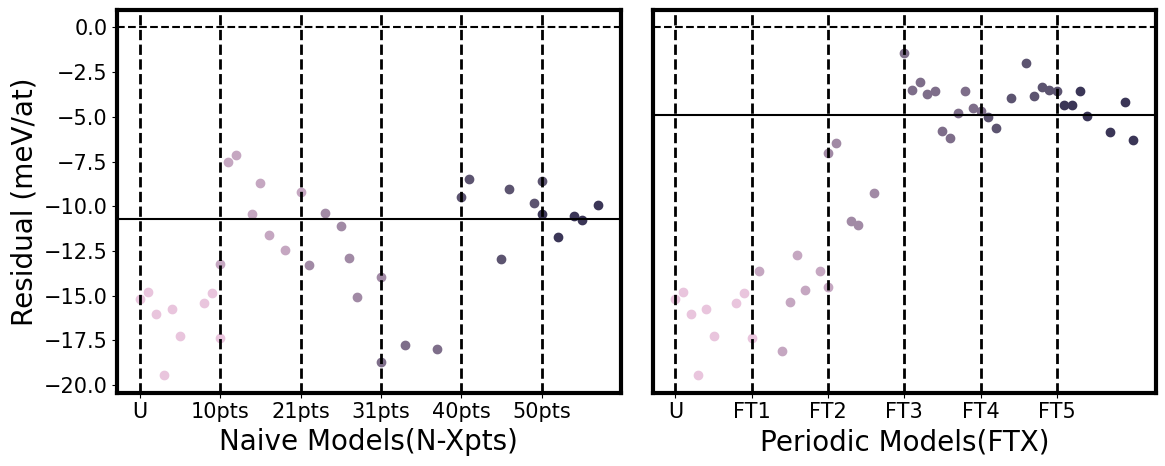

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5), sharey=True)
for idx, trajectory in enumerate(zip(Naive_Eval_DFT, Naive_Eval_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[0].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
for idx, trajectory in enumerate(zip(Periodic_Eval_DFT, Periodic_Eval_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[1].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax[1].set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
ax[0].set_xticks(np.arange(1,7), ['U', '10pts', '21pts', '31pts', '40pts', '50pts'])
ax[0].axhline(y=0, linestyle='--', color='black')
ax[0].axhline(y=-10.7, linestyle='-', color='black')

ax[1].axhline(y=0, linestyle='--', color='black')
ax[1].axhline(y=-4.87, linestyle='-', color='black')
ax[0].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[1].tick_params(axis='y', which='both', labelcolor=(0,0,0,0))
ax[1].tick_params(axis='y', which='both', color=(0,0,0,0))
ax[0].set_xlabel("Naive Models(N-Xpts)")
ax[1].set_xlabel("Periodic Models(FTX)")
ax[0].set_ylabel("Residual (meV/at)")
fig.tight_layout()
fig.savefig("./figures/results_modelEvaluations.svg")

## Independent Test Set

In [10]:
test_set = get_DFT_from_directory("../data/ChClCA_Evaluations/Independent_Test_Set")
periodic_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", ":")
naive_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", ":")
ft5_calc = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft5.model")
n50_calc = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/50pts.model")
ind_set = {}
root_folder = '../data/ChClCA_Evaluations/Independent_Test_Set'
for subdir, dirs, files in os.walk(root_folder):
    for file in files:
        if file == 'POSCAR':
            filepath = os.path.join(subdir, file)
            atom = read(filepath)
            match = re.search(r'eval\.(\d+)$', subdir)
            if(match):
                num = int(match.group(1))
                ind_set[num] = atom

Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/opt/anaconda3/envs/mace/lib/python3.13/site-packages/mace/calculators/mace.py:166: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/opt/anaconda3/envs/mace/lib/python3.13/site-packages/mace/calculators/mace.py:166: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


In [11]:
periodic_energies_dict = {}
naive_energies_dict = {}
for key in ind_set.keys():
    atom = ind_set.get(key)
    atom.calc = ft5_calc
    periodic_energies_dict[key] = atom.get_potential_energy()*1000/197
    atom.calc = N_50pts_model
    naive_energies_dict[key] = atom.get_potential_energy()*1000/197

In [15]:
test_energies_dict = {}
for key in test_set.keys():
    dftinfo = test_set.get(key)
    energy = dftinfo.energy * 1000 / 197
    test_energies_dict[key] = energy
periodic_residuals_dict = {}
nonperiodic_residuals_dict = {}
naive_residuals_dict = {}
for key in test_energies_dict.keys():
    periodic_residuals_dict[key] = [periodic_energies_dict.get(key)-test_energies_dict.get(key), test_energies_dict.get(key)]
    naive_residuals_dict[key] = [naive_energies_dict.get(key)-test_energies_dict.get(key), test_energies_dict.get(key)]


In [16]:
test_energies = []
test_energies = [test_set[s].energy * 1000 / 197 for s in test_set]
periodic_energies = [s.get_potential_energy() * 1000 / 197 for s in periodic_dataset]
naive_energies = [s.get_potential_energy() * 1000 / 197 for s in naive_dataset]

In [ ]:
def compute_binned_residuals(residual_dict, bin_edges):
    """
    Compute average residuals per bin from a residual dictionary.
    Fill gaps with NaN.
    """
    energies = np.array([v[1] for v in residual_dict.values()])
    residuals = np.array([v[0] for v in residual_dict.values()])
    bin_indices = np.digitize(energies, bin_edges)
    
    bin_sums = {}
    bin_counts = {}
    bin_sq_sums = {}
    for i, bin_idx in enumerate(bin_indices):
        if bin_idx not in bin_sums:
            bin_sums[bin_idx] = 0
            bin_counts[bin_idx] = 0
            bin_sq_sums[bin_idx] = 0.0
        bin_sums[bin_idx] += residuals[i]
        bin_counts[bin_idx] += 1
        bin_sq_sums[bin_idx] += residuals[i]**2
    
    bin_avg_residual = {bin_idx: bin_sums[bin_idx]/bin_counts[bin_idx] 
                        for bin_idx in bin_sums}
    bin_std_residual = {
        b: np.sqrt((bin_sq_sums[b] / bin_counts[b]) -(bin_avg_residual[b] ** 2))
        for b in bin_sums
    }

    all_bins = np.arange(min(bin_avg_residual.keys()), max(bin_avg_residual.keys()) + 1)
    avg_residual_array = np.array([bin_avg_residual.get(b, np.nan) for b in all_bins])
    std_array = np.array([bin_std_residual.get(b, np.nan) for b in all_bins])
    
    return all_bins, avg_residual_array, std_array


datasets = {
    'Test': test_energies,
    'Naive': naive_energies,
    'Periodic': periodic_energies,
}
all_energies = np.concatenate(list(datasets.values()))
min_edge = math.floor(all_energies.min())
max_edge = math.ceil(all_energies.max())
bin_edges = np.arange(min_edge, max_edge + 2, 2)
periodic_bins, periodic_avg_residual, periodic_std = compute_binned_residuals(periodic_residuals_dict, bin_edges)
naive_bins, naive_avg_residual, naive_std = compute_binned_residuals(naive_residuals_dict, bin_edges)

/var/folders/b3/hx8307zs7kl5xs560yl1xw4m0000gn/T/ipykernel_97525/2019695908.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


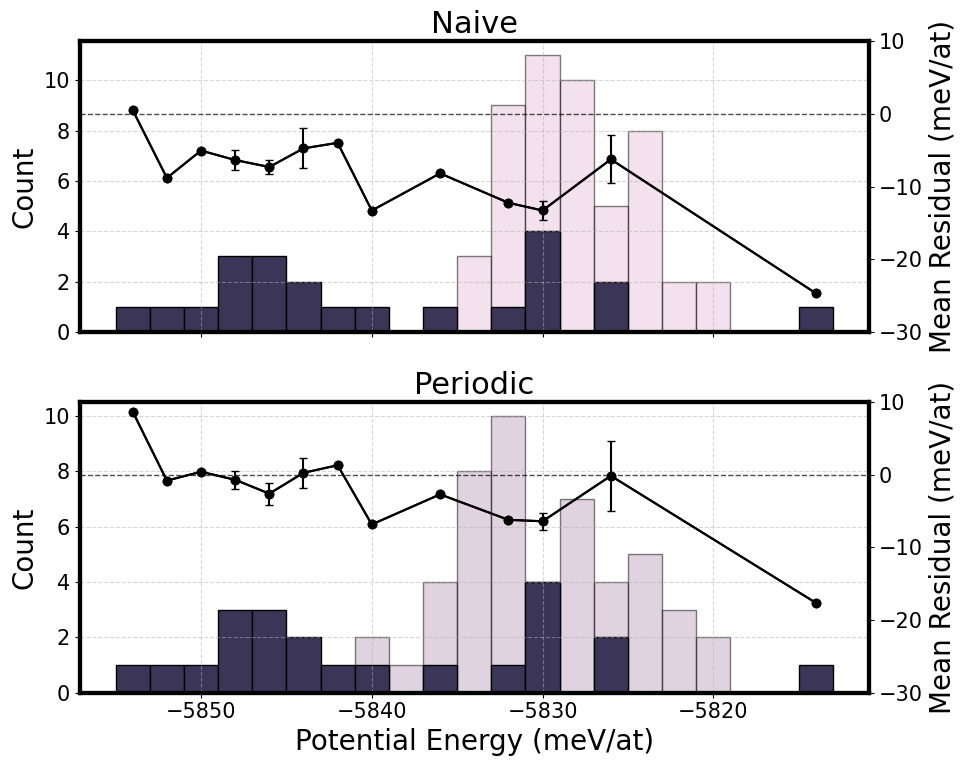

In [ ]:
# Data vs. evaluation energy histograms
datasets = {
    'Test': test_energies,
    'Naive': naive_energies,
    'Periodic': periodic_energies,
}
all_energies = np.concatenate(list(datasets.values()))
min_edge = math.floor(all_energies.min())
max_edge = math.ceil(all_energies.max())
bin_edges = np.arange(min_edge, max_edge + 2, 2)
datasets = {
    'Naive': naive_energies,
    'Periodic': periodic_energies
}
fig, axes = plt.subplots(len(datasets), 1, figsize=(10, 8), sharex=True)

for i, (ax, (label, data)) in enumerate(zip(axes, datasets.items())):
    ax.hist(data, bins=bin_edges, color=colors[i], edgecolor='black', alpha=0.5)
    ax.hist(test_energies, bins=bin_edges, color=colors[5], edgecolor='black', alpha=1)
    ax.set_title(label)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Count")
    if i == 0:
        ax2 = ax.twinx()
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        valid = ~np.isnan(naive_avg_residual)
        ax2.plot(bin_centers[valid], naive_avg_residual[valid], color='black', marker='o', linestyle='-')
        ax2.errorbar(
            bin_centers[valid],
            naive_avg_residual[valid],
            yerr=naive_std[valid],
            marker='o',
            linestyle='-',
            color='black',
            capsize=3
        )
        ax2.set_ylabel("Mean Residual (meV/at)")
        ax2.tick_params(axis='y')
        ax2.axhline(0, linewidth=1, linestyle='--', alpha=0.7, color='black')
        ax2.set_ylim(-30, 10)
    if i == 1:
        ax2 = ax.twinx()
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        valid = ~np.isnan(periodic_avg_residual)
        ax2.plot(bin_centers[valid], periodic_avg_residual[valid], color='black', marker='o', linestyle='-')
        ax2.errorbar(
            bin_centers[valid],
            periodic_avg_residual[valid],
            yerr=periodic_std[valid],
            marker='o',
            linestyle='-',
            color='black',
            capsize=3
        )
        ax2.set_ylabel("Mean Residual (meV/at)")
        ax2.tick_params(axis='y')
        ax2.axhline(0, linewidth=1, linestyle='--', alpha=0.7, color='black')
        ax2.set_ylim(-30, 10)
ax.set_xlabel("Potential Energy (meV/at)")
fig.tight_layout()
fig.show()
fig.savefig("figures/results_indTestEval.svg")


# SOAP/PCA Exploratory Data Analysis

In [ ]:
# Read data
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=':')
all_data = naive_set + ft_set
species = set()
for atoms in all_data:
    species.update(atoms.get_chemical_symbols())
species = list(species)
soap = SOAP(
    species=species,
    r_cut=5,
    n_max=8,
    l_max=6,
    sigma=0.375,
    periodic=True,
    sparse=False
)

In [ ]:
# Generate SOAP
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
ft_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
X_ft = np.array(ft_desc).reshape(-1, ft_desc[0].shape[-1])
X_all = np.vstack([X_naive, X_ft])
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_all)
X_naive_pca = X_pca[:len(X_naive)]
X_ft_pca = X_pca[len(X_naive):len(X_naive)+len(X_ft)]
explained_variance = pca.explained_variance_ratio_
print("Variance captured by each PC:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")
cumulative_variance = explained_variance.cumsum()
print("\nCumulative variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")


Variance captured by each PC:
PC1: 0.2300 (23.00%)
PC2: 0.1882 (18.82%)
PC3: 0.1164 (11.64%)
PC4: 0.0859 (8.59%)
PC5: 0.0686 (6.86%)

Cumulative variance:
PC1 to PC1: 0.2300 (23.00%)
PC1 to PC2: 0.4182 (41.82%)
PC1 to PC3: 0.5346 (53.46%)
PC1 to PC4: 0.6205 (62.05%)
PC1 to PC5: 0.6891 (68.91%)


## Compare Datasets

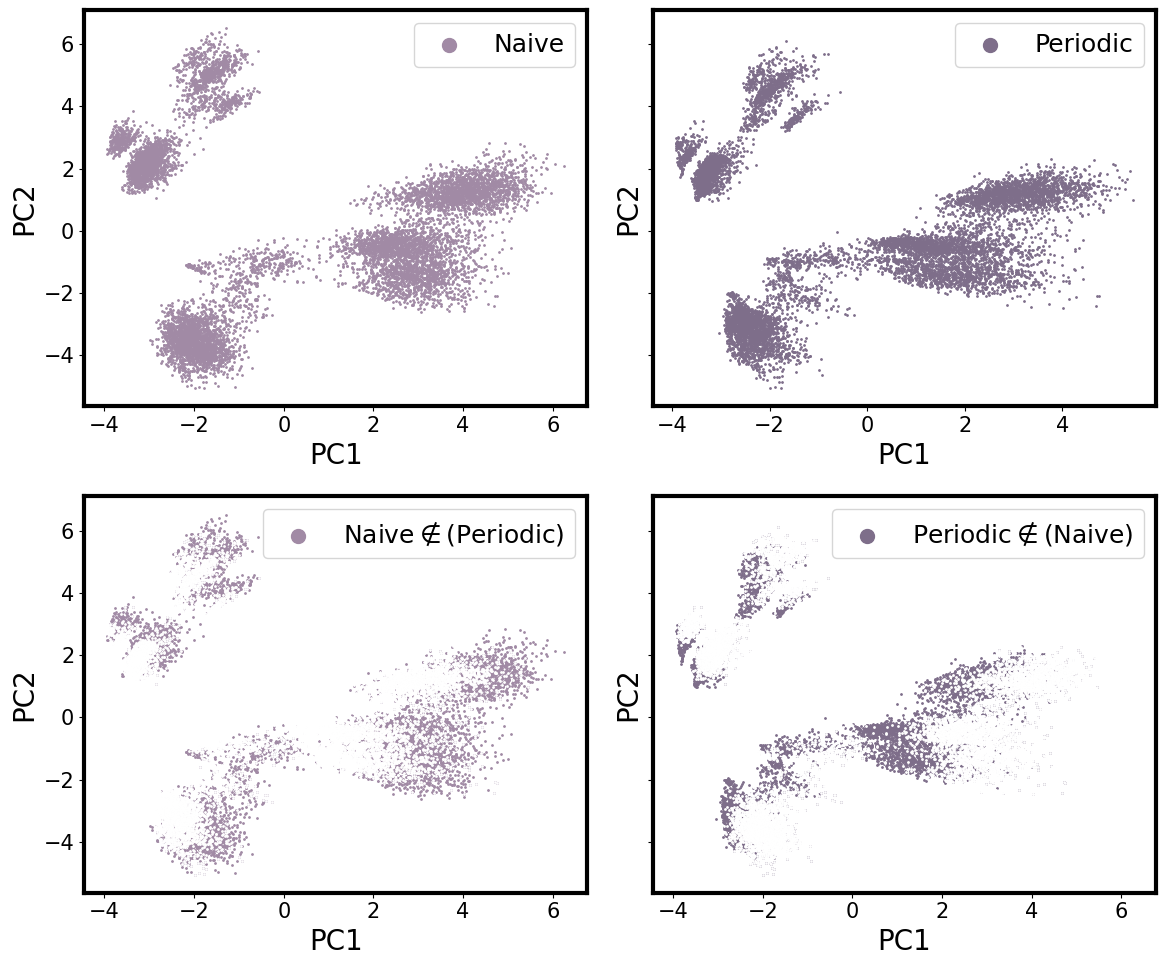

In [ ]:
# Plot 2x2 PCA plot with comparison of datasets
fig, ax = plt.subplots(2, 2, figsize = (12, 10), sharey=True,)
ax[0,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[3], 
           label='Periodic', rasterized=True)
ax[0,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[2], 
           label='Naive', rasterized=True)
ax[1,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[3], 
           label=r'Periodic$\notin$(Naive)', rasterized=True)
ax[1,1].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[2], 
           label=r'Naive$\notin$(Periodic)', rasterized=True)
ax[1,0].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
# for a in ax[1]:
#     a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
#     a.tick_params(axis='both', which='both', color=(0,0,0,0))
# for a in ax[0]:
#     a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
#     a.tick_params(axis='both', which='both', color=(0,0,0,0))
ax[1,1].set_xlabel("PC1")
ax[1,1].set_ylabel("PC2")
ax[1,0].set_xlabel("PC1")
ax[1,0].set_ylabel("PC2")
ax[0,1].set_xlabel("PC1")
ax[0,1].set_ylabel("PC2")
ax[0,0].set_xlabel("PC1")
ax[0,0].set_ylabel("PC2")
ax[1,1].legend(markerscale=10)
ax[1,0].legend(markerscale=10)
ax[0,0].legend(markerscale=10)
ax[0,1].legend(markerscale=10)
fig.tight_layout()
fig.savefig("figures/results_PCA_Datasets.svg")


## Dataset Growth Per Iteration

In [ ]:
# Read data for ft data
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data.xyz", index=':')
ft3_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft3_data.xyz", index=':')
ft2_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft2_data.xyz", index=':')
ft1_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft1_data.xyz", index=':')
u_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/u_data.xyz", index=':')
all_data = ft_set + ft3_set + ft2_set + ft1_set + u_set
species = set()
for atoms in all_data:
    species.update(atoms.get_chemical_symbols())
species = list(species)

In [ ]:
# Soap descriptors for ft data
ft4_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]
ft3_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft3_set]
ft2_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft2_set]
ft1_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft1_set]
u_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in u_set]
X_ft4   = np.array(ft4_desc).reshape(-1, ft4_desc[0].shape[-1])
X_ft3   = np.array(ft3_desc).reshape(-1, ft3_desc[0].shape[-1])
X_ft2   = np.array(ft2_desc).reshape(-1, ft2_desc[0].shape[-1])
X_ft1   = np.array(ft1_desc).reshape(-1, ft1_desc[0].shape[-1])
X_u     = np.array(u_desc).reshape(-1, u_desc[0].shape[-1])
X_ft4_pca   = pca.transform(X_ft4)
X_ft3_pca   = pca.transform(X_ft3)
X_ft2_pca   = pca.transform(X_ft2)
X_ft1_pca   = pca.transform(X_ft1)
X_u_pca     = pca.transform(X_u)



In [ ]:
# Read naive dataset
n50pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
n40pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-40pts/40pt_dataset_raw.xyz", index=':')
n31pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-31pts/31pt_dataset_raw.xyz", index=':')
n21pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-21pts/21pt_dataset_raw.xyz", index=':')
n10pt_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-10pts/10pt_dataset_raw.xyz", index=':')
all_naive_data = n10pt_set + n21pt_set + n31pt_set + n40pt_set + n50pt_set
species = set()
for atoms in all_naive_data:
    species.update(atoms.get_chemical_symbols())
species = list(species)

In [ ]:
# Generate SOAP for naive data
n10pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n10pt_set]
n21pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n21pt_set]
n31pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n31pt_set]
n40pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n40pt_set]
n50pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in n50pt_set]
X_n10pt = np.array(n10pt_desc).reshape(-1, n10pt_desc[0].shape[-1])
X_n21pt = np.array(n21pt_desc).reshape(-1, n21pt_desc[0].shape[-1])
X_n31pt = np.array(n31pt_desc).reshape(-1, n31pt_desc[0].shape[-1])
X_n40pt = np.array(n40pt_desc).reshape(-1, n40pt_desc[0].shape[-1])
X_n50pt = np.array(n50pt_desc).reshape(-1, n50pt_desc[0].shape[-1])
X_n50pt_pca = pca.transform(X_n50pt)
X_n40pt_pca = pca.transform(X_n40pt)
X_n21pt_pca = pca.transform(X_n21pt)
X_n31pt_pca = pca.transform(X_n31pt)
X_n10pt_pca = pca.transform(X_n10pt)



In [36]:
# np10pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-10pts/np10pt_dataset_raw.xyz", index=':')
# np21pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-21pts/np21pt_dataset_raw.xyz", index=':')
# np31pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-31pts/np31pt_dataset_raw.xyz", index=':')
# np40pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-40pts/np40pt_dataset_raw.xyz", index=':')
# np50pt_set = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-50pts/np50pt_dataset_raw.xyz", index=':')
# all_naive_data = np10pt_set + np21pt_set + np31pt_set + np40pt_set + n50pt_set
# species = set()
# for atoms in np50pt_set:
#     species.update(atoms.get_chemical_symbols())
# species = list(species)

In [ ]:
# np10pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np10pt_set]
# np21pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np21pt_set]
# np31pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np31pt_set]
# np40pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np40pt_set]
# np50pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np50pt_set]
# # np50pt_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in np50pt_set]
# X_np10pt = np.array(np10pt_desc).reshape(-1, np10pt_desc[0].shape[-1])
# X_np21pt = np.array(np21pt_desc).reshape(-1, np21pt_desc[0].shape[-1])
# X_np31pt = np.array(np31pt_desc).reshape(-1, np31pt_desc[0].shape[-1])
# X_np40pt = np.array(np40pt_desc).reshape(-1, np40pt_desc[0].shape[-1])
# X_np50pt = np.array(np50pt_desc).reshape(-1, np50pt_desc[0].shape[-1])
# # X_np50pt = np.array(np50pt_desc).reshape(-1, np50pt_desc[0].shape[-1])
# X_np50pt_pca   = pca.transform(X_np50pt)
# X_np40pt_pca   = pca.transform(X_np40pt)
# X_np31pt_pca   = pca.transform(X_np31pt)
# X_np21pt_pca   = pca.transform(X_np21pt)
# X_np10pt_pca   = pca.transform(X_np10pt)



In [38]:
# fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
# for ax in axes[:, 1:].ravel():
#     ax.set_ylabel("")
# for ax in axes[:-1, :].ravel():
#     ax.set_xlabel("")
# for ax in axes[:,0]:
#     ax.set_ylabel("PC2")

# for ax in axes[-1,:]:
#     ax.set_xlabel("PC1")
# axes = axes.T
# # Naive 
# # Panel 1
# axes[0,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
#                 alpha=1, s=3, color=colors[5], label=r"N-10",marker='.',rasterized=False)
# # Panel 2
# axes[1,0].scatter(X_n21pt_pca[:, 0], X_n21pt_pca[:, 1], 
#                 alpha=1, s=3, color=colors[5], label=r'N-21$\notin$(N-10)',marker='.',rasterized=False)
# axes[1,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
#                 alpha=1, s=3, color='white',marker='.', edgecolor='white',rasterized=False)
# # Panel 3
# axes[2,0].scatter(X_n31pt_pca[:, 0], X_n31pt_pca[:, 1], 
#                 alpha=1, s=3, color=colors[5], label=r'N-31$\notin$(N-21, N-10)',marker='.',rasterized=False)
# axes[2,0].scatter(X_n21pt_pca[:, 0], X_n21pt_pca[:, 1], 
#                 alpha=1, s=3, color='white',marker='.', edgecolor='white',rasterized=False)
# axes[2,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
#                 alpha=1, s=3, color='white',marker='.', edgecolor='white',rasterized=False)
# # Panel 4
# axes[3,0].scatter(X_n40pt_pca[:, 0], X_n40pt_pca[:, 1], 
#                 alpha=1, s=3, color=colors[5], label=r'N-40$\notin$(N-31, N-21, N-10)',marker='.',rasterized=False)
# axes[3,0].scatter(X_n31pt_pca[:, 0], X_n31pt_pca[:, 1], 
#                 alpha=1, s=3, color='white', edgecolor=None,marker='.',rasterized=False)
# axes[3,0].scatter(X_n21pt_pca[:, 0], X_n21pt_pca[:, 1], 
#                 alpha=1, s=3, color='white', edgecolor=None,marker='.',rasterized=False)
# axes[3,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
#                 alpha=1, s=3, color='white', edgecolor=None,marker='.',rasterized=False)

# # Plot Periodic
# # Panel 1
# axes[0,1].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
#                 alpha=1, s=3, color=colors[5], label=r'U',marker='.',rasterized=False)
# # Panel 2
# axes[1,1].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
#                 alpha=1, s=3, color=colors[5], label=r'FT1$\notin$(U)', marker='.',rasterized=False)
# axes[1,1].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
#                 alpha=1, s=3, color='white', marker='.',rasterized=False)
# # Panel 3
# axes[2,1].scatter(X_ft2_pca[:, 0], X_ft2_pca[:, 1], 
#                 alpha=1, s=3, color=colors[5], label=r"FT2$\notin$(U, FT1)",marker='.',rasterized=False)
# axes[2,1].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
#                 alpha=1, s=3, color='white',marker='.',rasterized=False)
# axes[2,1].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
#                 alpha=1, s=3, color='white',marker='.',rasterized=False)
# # Panel 4
# axes[3,1].scatter(X_ft3_pca[:, 0], X_ft3_pca[:, 1], 
#                 alpha=1, s=3, color=colors[5], label=r"FT3$\notin$(U, FT1, FT2)",marker='.',rasterized=False)
# axes[3,1].scatter(X_ft2_pca[:, 0], X_ft2_pca[:, 1], 
#                 alpha=1, s=3, color='#FFFFFF', marker='.',rasterized=False)
# axes[3,1].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
#                 alpha=1, s=3, color='#FFFFFF', marker='.',rasterized=False)
# axes[3,1].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
#                 alpha=1, s=3, color='#FFFFFF', marker='.',rasterized=False)
# for a in axes.flatten():
#     a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
#     a.tick_params(axis='both', which='both', color=(0,0,0,0))
# fig.tight_layout()
# fig.savefig("figures/results_PCA_per_iteration.svg")
# fig.show()


In [ ]:
# Bond lengths for naive environments
dataset = read("../data/ChClCA_Finetuning/Naive/Model:U/md/1/1_ase.xyz", "::1")[1000:]
dataset_2 = read("../data/ChClCA_Finetuning/Naive/Model:U/md/2/2_ase.xyz", "::1")[1000:]
bond_type = ["C", "H"]
all_frames = []
dataset_1_bonds = []
dataset_1_hcl_bonds = []
dataset_1_co_bonds = []
dataset_2_bonds = []
dataset_2_hcl_bonds = []
dataset_2_co_bonds = []
for atoms in dataset:
    Z = atoms.get_atomic_numbers()
    symbols = atoms.get_chemical_symbols()
    cutoffs = [1.5 * covalent_radii[z] for z in Z]
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    bond_lengths = []
    for i in range(len(atoms)):
        neighbors, offsets = nl.get_neighbors(i)
        for j in neighbors:
            if j > i:
                d = atoms.get_distance(i, j, mic=True)
                if ((symbols[i] == bond_type[0] and symbols[j] == bond_type[1]) or (symbols[i] == bond_type[0] and symbols[j] == bond_type[1])) and d < 1.25:
                    dataset_1_bonds.append(d)
                if (((symbols[i] == "H" and symbols[j] == "Cl") or (symbols[i] == "Cl" and symbols[j] == "H")) and d < 1.6):
                    dataset_1_hcl_bonds.append(d)
                if (((symbols[i] == "C" and symbols[j] == "O") or (symbols[i] == "O" and symbols[j] == "C")) and d < 1.60):
                    dataset_1_co_bonds.append(d)
for atoms in dataset_2:
    Z = atoms.get_atomic_numbers()
    symbols = atoms.get_chemical_symbols()
    cutoffs = [1.5 * covalent_radii[z] for z in Z]
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    bond_lengths = []
    for i in range(len(atoms)):
        neighbors, offsets = nl.get_neighbors(i)
        for j in neighbors:
            if j > i:
                d = atoms.get_distance(i, j, mic=True)
                if ((symbols[i] == bond_type[0] and symbols[j] == bond_type[1]) or (symbols[i] == bond_type[0] and symbols[j] == bond_type[1])) and d < 1.25:
                    dataset_2_bonds.append(d)
                if (((symbols[i] == "H" and symbols[j] == "Cl") or (symbols[i] == "Cl" and symbols[j] == "H")) and d < 1.6):
                    dataset_2_hcl_bonds.append(d)
                if (((symbols[i] == "C" and symbols[j] == "O") or (symbols[i] == "O" and symbols[j] == "C")) and d < 1.60):
                    dataset_2_co_bonds.append(d)

In [ ]:
# Bond lengths for periodic environments
dataset_p = read("../data/ChClCA_Finetuning/Periodic/Model:U/md/u_ase.xyz", "::1")[1000:]
dataset_2_p = read("../data/ChClCA_Finetuning/Periodic/Model:FT1/md/FT1_ase.xyz", "::1")[1000:]
bond_type = ["O", "H"]
all_frames = []
dataset_1_bonds_p = []
dataset_1_hcl_bonds_p = []
dataset_1_co_bonds_p = []
dataset_2_bonds_p = []
dataset_2_hcl_bonds_p = []
dataset_2_co_bonds_p = []
for atoms in dataset_p:
    Z = atoms.get_atomic_numbers()
    symbols = atoms.get_chemical_symbols()
    cutoffs = [1.5 * covalent_radii[z] for z in Z]
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    bond_lengths = []
    for i in range(len(atoms)):
        neighbors, offsets = nl.get_neighbors(i)
        for j in neighbors:
            if j > i:
                d = atoms.get_distance(i, j, mic=True)
                if ((symbols[i] == bond_type[0] and symbols[j] == bond_type[1]) or (symbols[i] == bond_type[0] and symbols[j] == bond_type[1])) and d < 1.25:
                    dataset_1_bonds_p.append(d)
                if (((symbols[i] == "H" and symbols[j] == "Cl") or (symbols[i] == "Cl" and symbols[j] == "H")) and d < 1.6):
                    dataset_1_hcl_bonds_p.append(d)
                if (((symbols[i] == "C" and symbols[j] == "O") or (symbols[i] == "O" and symbols[j] == "C")) and d < 1.60):
                    dataset_1_co_bonds_p.append(d)
for atoms in dataset_2_p:
    Z = atoms.get_atomic_numbers()
    symbols = atoms.get_chemical_symbols()
    cutoffs = [1.5 * covalent_radii[z] for z in Z]
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    bond_lengths = []
    for i in range(len(atoms)):
        neighbors, offsets = nl.get_neighbors(i)
        for j in neighbors:
            if j > i:
                d = atoms.get_distance(i, j, mic=True)
                if ((symbols[i] == bond_type[0] and symbols[j] == bond_type[1]) or (symbols[i] == bond_type[0] and symbols[j] == bond_type[1])) and d < 1.25:
                    dataset_2_bonds_p.append(d)
                if (((symbols[i] == "H" and symbols[j] == "Cl") or (symbols[i] == "Cl" and symbols[j] == "H")) and d < 1.6):
                    dataset_2_hcl_bonds_p.append(d)
                if (((symbols[i] == "C" and symbols[j] == "O") or (symbols[i] == "O" and symbols[j] == "C")) and d < 1.60):
                    dataset_2_co_bonds_p.append(d)



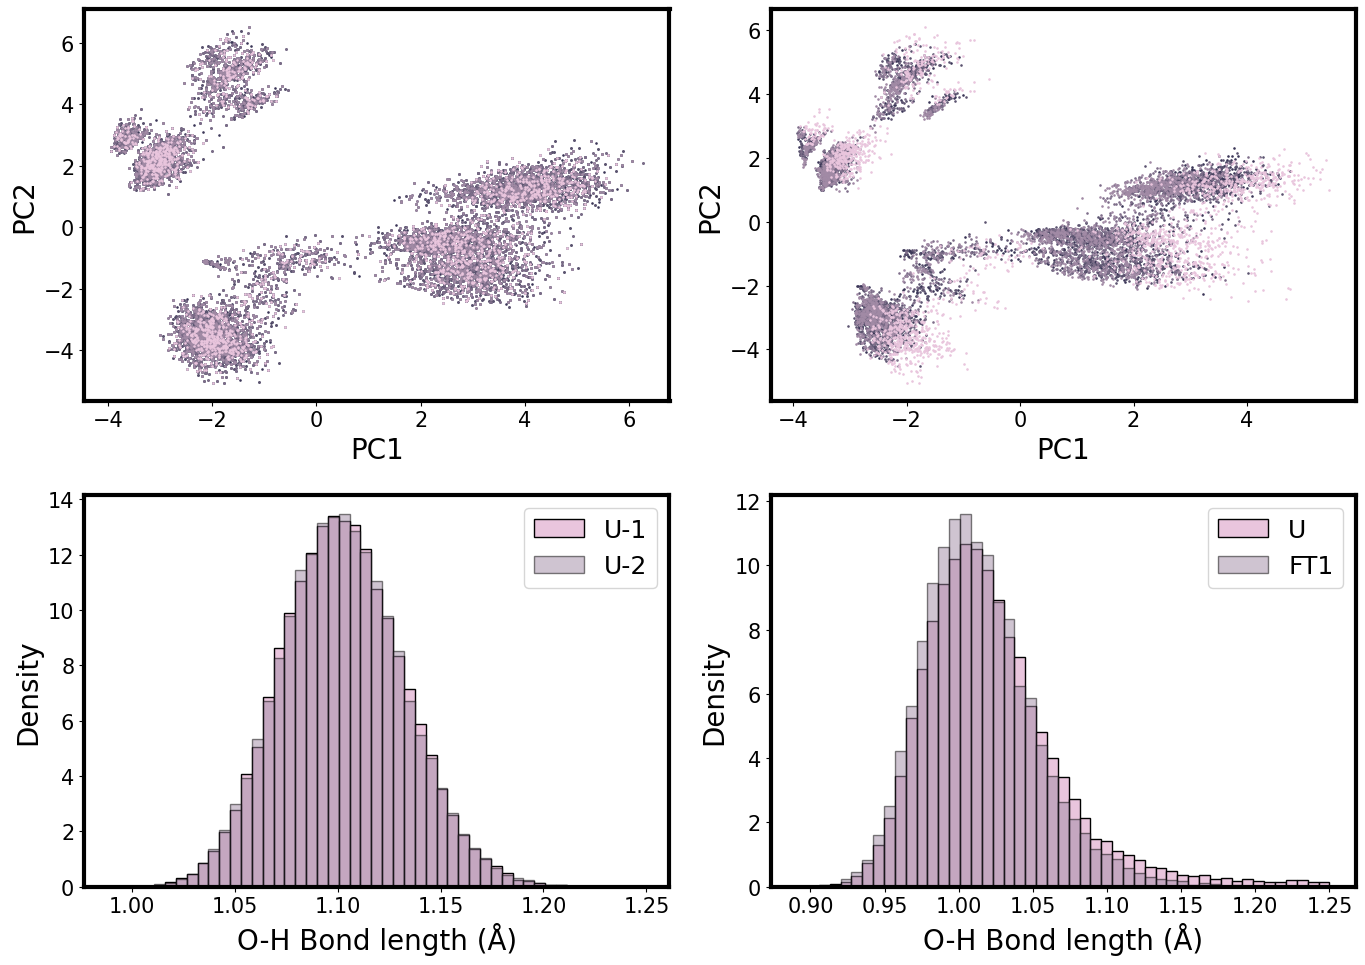

In [ ]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
# Naive 
axes[0,0].scatter(X_n50pt_pca[:, 0], X_n50pt_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'N-40$\notin$(N-31, N-21, N-10)',marker='.',rasterized=True)
axes[0,0].scatter(X_n40pt_pca[:, 0], X_n40pt_pca[:, 1], 
                alpha=1, s=3, color=colors[4], label=r'N-40$\notin$(N-31, N-21, N-10)',marker='.',rasterized=True)
axes[0,0].scatter(X_n31pt_pca[:, 0], X_n31pt_pca[:, 1], 
                alpha=1, s=3, color=colors[3], label=r'',marker='.',rasterized=True)
axes[0,0].scatter(X_n21pt_pca[:, 0], X_n21pt_pca[:, 1], 
                alpha=1, s=3, color=colors[2], label=r'',marker='.',rasterized=True)
axes[0,0].scatter(X_n10pt_pca[:, 0], X_n10pt_pca[:, 1], 
                alpha=1, s=3, color=colors[0], label=r"N-10",marker='.',rasterized=True)
# Periodic
axes[0,1].scatter(X_ft4_pca[:, 0], X_ft4_pca[:, 1], 
                alpha=1, s=3, color=colors[5], label=r'U',marker='.',rasterized=True)
axes[0,1].scatter(X_ft3_pca[:, 0], X_ft3_pca[:, 1], 
                alpha=1, s=3, color=colors[4], label=r'U',marker='.',rasterized=True)
axes[0,1].scatter(X_ft2_pca[:, 0], X_ft2_pca[:, 1], 
                alpha=1, s=3, color=colors[3], label=r'U',marker='.',rasterized=True)
axes[0,1].scatter(X_ft1_pca[:, 0], X_ft1_pca[:, 1], 
                alpha=1, s=3, color=colors[2], label=r'U',marker='.',rasterized=True)
axes[0,1].scatter(X_u_pca[:, 0], X_u_pca[:, 1], 
                alpha=1, s=3, color=colors[0], label=r'U',marker='.',rasterized=True)
# Plot histograms of O-H bond lengths
combined = np.concatenate([dataset_1_bonds_p, dataset_2_bonds_p])
bins = np.linspace(combined.min(), combined.max(), 50)
axes[1,1].hist(dataset_1_bonds_p, bins=bins, alpha=1, color=colors[0], edgecolor='black', density=True, label='U')
axes[1,1].hist(dataset_2_bonds_p, bins=bins, alpha=0.5, color=colors[2], edgecolor='black', density=True, label='FT1')
axes[1,1].set_xlabel("O-H Bond length (Å)")
axes[1,1].set_ylabel("Density")
axes[1,1].legend()
combined = np.concatenate([dataset_1_bonds, dataset_2_bonds])
bins = np.linspace(combined.min(), combined.max(), 50)
axes[1,0].hist(dataset_1_bonds, bins=bins, alpha=1, color=colors[0], edgecolor='black', density=True, label='U-1')
axes[1,0].hist(dataset_2_bonds, bins=bins, alpha=0.5, color=colors[2], edgecolor='black', density=True, label='U-2')
axes[1,0].set_xlabel("O-H Bond length (Å)")
axes[1,0].set_ylabel("Density")
axes[1,0].legend()
xlim = ax[0,0].get_xlim() 
ylim = ax[0,0].get_ylim() 
ax[0,1].set_xlim(xlim) 
ax[0,1].set_ylim(ylim)
axes[0,0].set_xlabel("PC1", fontsize=20)
axes[0,0].set_ylabel("PC2", fontsize=20)
axes[0,1].set_xlabel("PC1", fontsize=20)
axes[0,1].set_ylabel("PC2", fontsize=20)
fig.tight_layout()
fig.savefig("figures/results_PCA_per_iteration_2.svg")
fig.show()


In [ ]:
# SI, CO bond lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False, sharey=False)
combined = np.concatenate([dataset_1_co_bonds_p, dataset_2_co_bonds_p])
bins = np.linspace(combined.min(), combined.max(), 50)
axes[1].hist(dataset_1_co_bonds_p, bins=bins, alpha=1, color=colors[0], edgecolor='black', density=True, label='U')
axes[1].hist(dataset_2_co_bonds_p, bins=bins, alpha=0.5, color=colors[2], edgecolor='black', density=True, label='FT1')
axes[1].set_xlabel("C-O Bond length (Å)")
axes[1].set_ylabel("Density")
axes[1].legend()
combined = np.concatenate([dataset_1_co_bonds, dataset_2_co_bonds])
bins = np.linspace(combined.min(), combined.max(), 50)
axes[0].hist(dataset_1_co_bonds, bins=bins, alpha=1, color=colors[0], edgecolor='black', density=True, label='U-1')
axes[0].hist(dataset_2_co_bonds, bins=bins, alpha=0.5, color=colors[2], edgecolor='black', density=True, label='U-2')
axes[0].set_xlabel("C-O Bond length (Å)")
axes[0].set_ylabel("Density")
axes[0].legend()
fig.savefig("./supplemental_figs/SI_CO_BondLengthDistribution.svg")

In [ ]:
# SI, HCl bond lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False, sharey=False)
combined = np.concatenate([dataset_1_hcl_bonds_p, dataset_2_hcl_bonds_p])
bins = np.linspace(combined.min(), combined.max(), 50)
axes[1].hist(dataset_1_hcl_bonds_p, bins=bins, alpha=1, color=colors[0], edgecolor='black', density=True, label='U')
axes[1].hist(dataset_2_hcl_bonds_p, bins=bins, alpha=0.5, color=colors[2], edgecolor='black', density=True, label='FT1')
axes[1].set_xlabel("H-Cl Bond length (Å)")
axes[1].set_ylabel("Density")
axes[1].legend()
combined = np.concatenate([dataset_1_hcl_bonds, dataset_2_hcl_bonds])
bins = np.linspace(combined.min(), combined.max(), 50)
axes[0].hist(dataset_1_hcl_bonds, bins=bins, alpha=1, color=colors[0], edgecolor='black', density=True, label='U-1')
axes[0].hist(dataset_2_hcl_bonds, bins=bins, alpha=0.5, color=colors[2], edgecolor='black', density=True, label='U-2')
axes[0].set_xlabel("H-Cl Bond length (Å)")
axes[0].set_ylabel("Density")
axes[0].legend()
fig.savefig("./supplemental_figs/SI_HCl_BondLengthDistribution.svg")

# Long Trajectory Analysis

In [ ]:
# Read data
Periodic_Long_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Long_Runs/Periodic/dft")
Naive_Long_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Long_Runs/Naive/dft")
Periodic_Long_MD = pd.read_csv("../data/ChClCA_Evaluations/Long_Runs/Periodic/md/run_info.txt", sep='\t')
Naive_Long_MD = pd.read_csv("../data/ChClCA_Evaluations/Long_Runs/Naive/md/run_info.txt", sep='\t')
Naive_traj = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_1_ase.xyz", "::200") + read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_2_ase.xyz", '::200')
Periodic_traj = read("../data/ChClCA_Evaluations/Long_Runs/Periodic/md/long_periodic_1_ase.xyz", "::200")+read("../data/ChClCA_Evaluations/Long_Runs/Periodic/md/long_periodic_2_ase.xyz", '::200')

In [ ]:
# Compute MLIP evals
periodic_on_naive = []
naive_on_periodic = []
meV_per_atom = 1000/197
for image in Naive_traj:
    image.calc = FT5_model
    periodic_on_naive.append(image.get_potential_energy()*meV_per_atom)
for image in Periodic_traj:
    image.calc = N_50pts_model
    naive_on_periodic.append(image.get_potential_energy()*meV_per_atom)


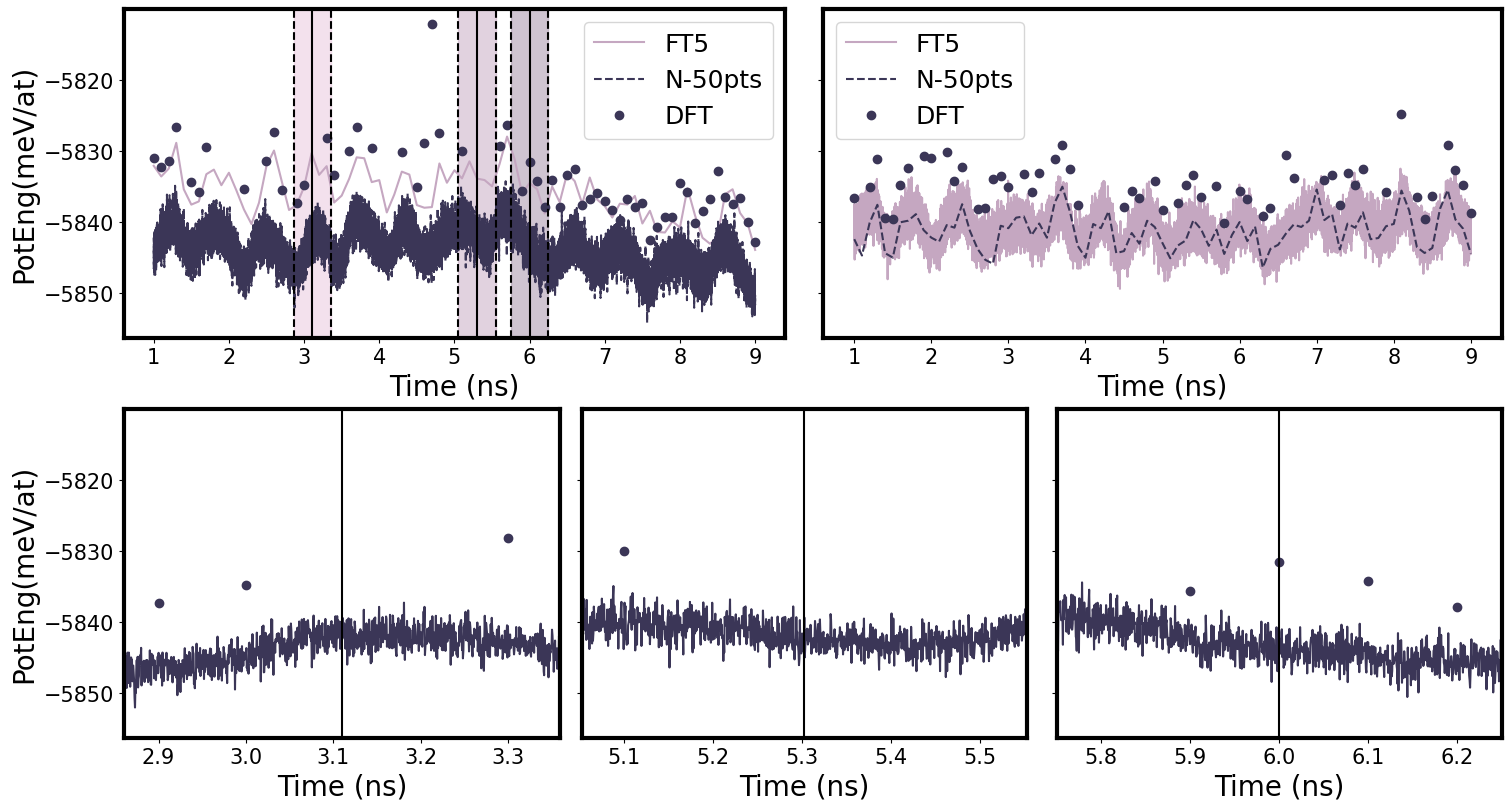

In [ ]:
# Plot each long trajectory against DFT

fig = plt.figure(figsize=(15, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 6, figure=fig)

ax0 = fig.add_subplot(gs[0, 0:3])
ax1 = fig.add_subplot(gs[0, 3:6], sharey=ax0)

ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4], sharey=ax2)
ax4 = fig.add_subplot(gs[1, 4:6], sharey=ax2)
x_axis = np.linspace(0, 9, 18001)



ax0.plot(x_axis[2000:][::200], periodic_on_naive[10:], '-', color=colors[1], label='FT5')
ax0.plot(x_axis[2000:], Naive_Long_MD['PotEng'][2000:] * meV_per_atom, '--', color=colors[5], label='N-50pts')
keys, vals = zip(*Naive_Long_DFT.items())
energies = np.array([v.energy for v in vals])
ax0.plot(np.array(keys)/2000, energies * meV_per_atom, '.', color=colors[5], markersize=12, label='DFT')
ax2.plot(np.array(keys)/2000, energies * meV_per_atom, '.', color=colors[5], markersize=12, label='DFT')
ax2.set_xlim([2.86, 3.36])
ax3.plot(np.array(keys)/2000, energies * meV_per_atom, '.', color=colors[5], markersize=12, label='DFT')
ax3.set_xlim([5.0525, 5.5525])
ax4.plot(np.array(keys)/2000, energies * meV_per_atom, '.', color=colors[5], markersize=12, label='DFT')
ax4.set_xlim([5.75, 6.25])
ax0.axvline(2.86, ls='dashed', color='black')
ax0.axvline(3.36, ls='dashed', color='black')
ax0.axvspan(2.86, 3.36, color=colors[0], alpha=0.5)
ax0.axvline(5.0525, ls='dashed', color='black')
ax0.axvspan(5.0525,5.5525, color=colors[1], alpha=0.5)
ax0.axvline(5.5525, ls='dashed', color='black')
ax0.axvline(5.75, ls='dashed', color='black')
ax0.axvline(6.25, ls='dashed', color='black')
ax0.axvspan(5.75,6.25, color=colors[2], alpha=0.5)
ax1.plot(x_axis[2000:], Periodic_Long_MD['PotEng'][2000:] * meV_per_atom, '-', color=colors[1], label='FT5')
ax1.plot(x_axis[2000:][::200], naive_on_periodic[10:], '--', color=colors[5], label='N-50pts')

keys, vals = zip(*Periodic_Long_DFT.items())
energies = np.array([v.energy for v in vals])
ax1.plot(np.array(keys)/2000, energies * meV_per_atom, '.', color=colors[5], markersize=12, label='DFT')

ax2.set_xlabel("Time (ns)")
ax3.set_xlabel("Time (ns)")
ax4.set_xlabel("Time (ns)")
ax2.plot(x_axis[2000:], Naive_Long_MD['PotEng'][2000:]*meV_per_atom, color=colors[5])
ax2.axvline(3.110, color='black')
ax0.axvline(3.110, color='black')
ax3.plot(x_axis[10105:11105], Naive_Long_MD['PotEng'][10105:11105]*meV_per_atom, color=colors[5])
ax3.axvline(5.3025, color='black')
ax0.axvline(5.3025, color='black')
ax4.plot(x_axis[11500:12500], Naive_Long_MD['PotEng'][11500:12500]*meV_per_atom, color=colors[5])
ax4.axvline(6, color='black')
ax0.axvline(6, color='black')
ax0.legend()
ax1.legend()
ax0.set_ylabel("PotEng(meV/at)")
ax2.set_ylabel("PotEng(meV/at)")
ax0.set_xlabel("Time (ns)")
ax1.set_xlabel("Time (ns)")
plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.setp(ax4.get_yticklabels(), visible=False)
fig.savefig("figures/results_longEval_detailed.svg", bbox_inches="tight")
plt.show()


In [ ]:
# generate SOAP for each dataset
naive_eval_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in Naive_traj]
X_eval_naive = np.array(naive_eval_desc).reshape(-1, naive_eval_desc[0].shape[-1])
X_eval_naive_pca = pca.transform(X_eval_naive)
periodic_eval_desc   =  [soap.create(atoms, centers=atoms.get_positions()) for atoms in Periodic_traj]
X_eval_periodic = np.array(periodic_eval_desc).reshape(-1, periodic_eval_desc[0].shape[-1])
X_eval_periodic_pca = pca.transform(X_eval_periodic)
X_eval_naive_pca_r = X_eval_naive_pca.reshape(91, 197, 5)
X_eval_periodic_pca_r = X_eval_periodic_pca.reshape(91, 197, 5)

In [49]:
# fig, ax = plt.subplots(2, 4, figsize=(24,10), sharey=True, sharex=True)

# ax[0,0].scatter(X_eval_naive_pca_r[10:30, :, 0], X_eval_naive_pca_r[10:30, :, 1],
#            alpha=1, label="Naive Trajectory", s=1, color=colors[5], rasterized=True)
# ax[0,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', 
#            label='Naive Dataset', rasterized=True)

# ax[0,1].scatter(X_eval_naive_pca_r[30:50, :, 0], X_eval_naive_pca_r[30:50, :, 1],
#            alpha=1, label="Naive Trajectory", s=1, color=colors[5], rasterized=True)
# ax[0,1].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', 
#            label='Naive Dataset', rasterized=True)

# ax[0,2].scatter(X_eval_naive_pca_r[60:80, :, 0], X_eval_naive_pca_r[60:80, :, 1],
#            alpha=1, label="Naive Trajectory", s=1, color=colors[5], rasterized=True)
# ax[0,2].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', 
#            label='Naive Dataset', rasterized=True)

# ax[0,3].scatter(X_eval_naive_pca_r[70:90, :, 0], X_eval_naive_pca_r[70:90, :, 1],
#            alpha=1, label="Naive Trajectory", s=1, color=colors[5], rasterized=True)
# ax[0,3].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', 
#            label='Naive Dataset', rasterized=True)

# ax[1,0].scatter(X_eval_periodic_pca_r[10:30, :, 0], X_eval_periodic_pca_r[10:30, :, 1],
#            alpha=1, label="Periodic Trajectory", s=1, color=colors[5], rasterized=True)
# ax[1,0].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', 
#            label='Periodic Dataset', rasterized=True)
# ax[1,1].scatter(X_eval_periodic_pca_r[30:50, :, 0], X_eval_periodic_pca_r[30:50, :, 1],
#            alpha=1, label="Periodic Trajectory", s=1, color=colors[5], rasterized=True)
# ax[1,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', 
#            label='Periodic Dataset', rasterized=True)
# ax[1,2].scatter(X_eval_periodic_pca_r[50:70, :, 0], X_eval_periodic_pca_r[50:70, :, 1],
#            alpha=1, label="Periodic Trajectory", s=1, color=colors[5], rasterized=True)
# ax[1,2].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', 
#            label='Periodic Dataset', rasterized=True)
# ax[1,3].scatter(X_eval_periodic_pca_r[70:90, :, 0], X_eval_periodic_pca_r[70:90, :, 1],
#            alpha=1, label="Periodic Trajectory", s=1, color=colors[5], rasterized=True)
# ax[1,3].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', 
#            label='Periodic Dataset', rasterized=True)
# for a in ax.flatten():
#     a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
#     a.tick_params(axis='both', which='both', color=(0,0,0,0))
# ax[0,0].set_ylabel("PC2")
# ax[1,0].set_ylabel("PC2")
# ax[1,0].set_xlabel("PC1")
# ax[1,1].set_xlabel("PC1")
# ax[1,2].set_xlabel("PC1")
# ax[1,3].set_xlabel("PC1")
# fig.show()
# fig.tight_layout()
# fig.savefig("figures/results_trajDatasets_PCA.svg")

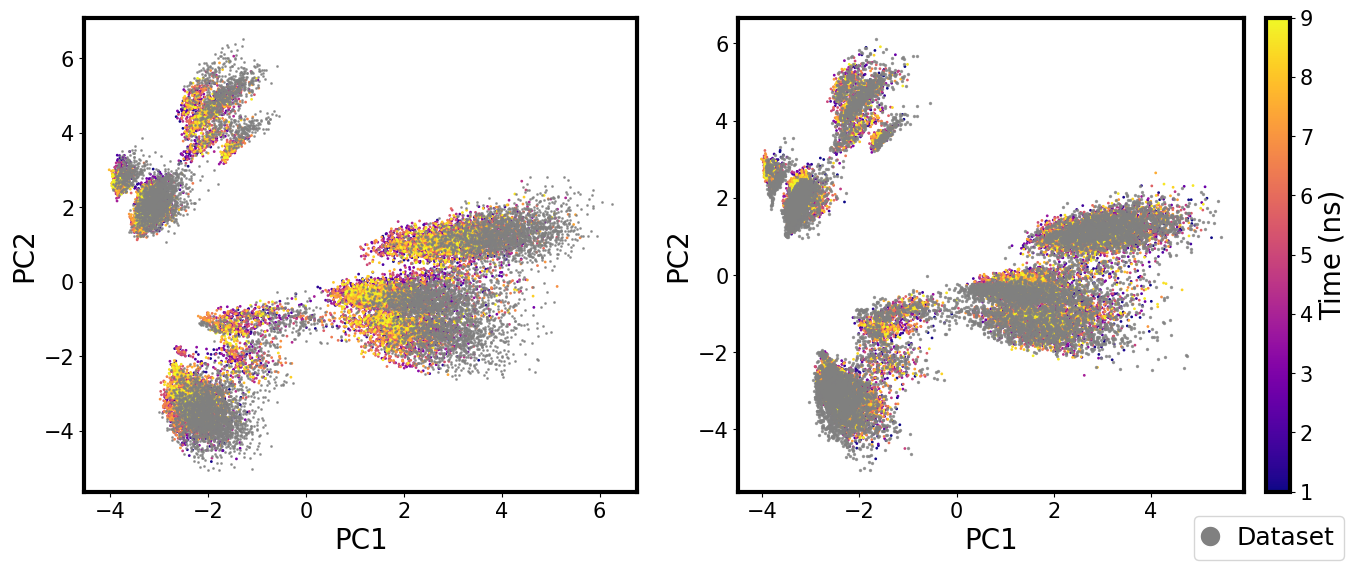

In [ ]:
# Compute trajectory over time against dataset
fig, ax = plt.subplots(1, 2, figsize=(14,6))
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", colors[::-1])

time_naive = np.arange(X_eval_naive_pca_r.shape[0])[10:, None]/10
time_naive = np.repeat(time_naive, X_eval_naive_pca_r.shape[1], axis=1)

sc1 = ax[0].scatter(X_eval_naive_pca_r[10:,:,0].flatten(), X_eval_naive_pca_r[10:,:,1].flatten(), c=time_naive.flatten(),
    cmap='plasma', s=1, alpha=1, label="Naive Trajectory", rasterized=True)
ax[0].scatter(X_naive_pca[:,0], X_naive_pca[:,1], s=1, color='grey', alpha=0.75, label='Naive Dataset', rasterized=True,)

time_periodic = np.arange(X_eval_periodic_pca_r.shape[0])[:, None]
time_periodic = np.repeat(time_periodic, X_eval_periodic_pca_r.shape[1], axis=1)

sc2 = ax[1].scatter(X_eval_periodic_pca_r[:,:,0].flatten(), X_eval_periodic_pca_r[:,:,1].flatten(), 
    c=time_periodic.flatten(), cmap='plasma', s=1, alpha=1, label="Periodic Trajectory", rasterized=True)
ax[1].scatter(X_ft_pca[:,0], X_ft_pca[:,1], s=2, color='grey', alpha=0.75, label='Periodic Dataset', rasterized=True)
for i in ax:
    i.set_xlabel("PC1", fontsize=20)
    i.set_ylabel("PC2", fontsize=20)
    i.set_title("")
cbar1 = plt.colorbar(sc1, ax=ax[1], fraction=0.046, pad=0.04)
dataset_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=15, alpha=1, label='Dataset')
ax[1].legend(handles=[dataset_handle], loc='upper left', bbox_to_anchor=(0.875, -0.025), frameon=True, handlelength=0.5)
cbar1.set_label("Time (ns)")
plt.tight_layout()
fig.show()
fig.savefig("figures/results_trajDatasets_PCA_2D.svg")


# Q Residuals

In [37]:
def compute_q_residuals(pca, X):
    """
    Compute Q-residuals (orthogonal distances) for samples X
    given a fitted scikit-learn PCA model.
    """
    scores = pca.transform(X)
    X_reconstructed = np.dot(scores, pca.components_) + pca.mean_
    residuals = X - X_reconstructed
    q_residuals = np.sum(residuals**2, axis=1)
    return q_residuals
def q_residual_inputs(soap, pca_dataset, trajectory_eval, n_pca_components=5):
    eval_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in trajectory_eval]
    eval_desc = np.array(eval_desc).reshape(-1, eval_desc[0].shape[-1])
    pca_set = [soap.create(atoms, centers=atoms.get_positions()) for atoms in pca_dataset]
    X_pca_set_set = np.array(pca_set).reshape(-1, pca_set[0].shape[-1])
    pca = PCA(n_components=n_pca_components)
    X_pca = pca.fit_transform(X_pca_set_set)
    explained_variance = pca.explained_variance_ratio_
    print("Variance captured by each PC:")
    for i, var in enumerate(explained_variance):
        print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

    # Cumulative variance
    cumulative_variance = explained_variance.cumsum()
    print("\nCumulative variance:")
    for i, cum_var in enumerate(cumulative_variance):
        print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")
    return pca, eval_desc
def plot_q_residuals(pca, eval_desc, colors, remapped, n_atoms=21, plot=True):
    total_sum = 0
    num_slices = 197
    slice_length = n_atoms
    for i in range(num_slices):
        residuals = compute_q_residuals(pca, eval_desc[i::num_slices])
        color = 'black' if i == 0 else colors[remapped[i]]
        if(plot):
            plt.plot(residuals, color=color)
        total_sum += np.sum(residuals)
    average_residual = total_sum / num_slices / slice_length
    print(average_residual)
    return average_residual

## Testing

In [43]:
Naive_traj = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_1_ase.xyz", "::100") + read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_2_ase.xyz", '::100')
Periodic_traj = read("../data/ChClCA_Evaluations/Long_Runs/Periodic/md/long_periodic_1_ase.xyz", "::100")+read("../data/ChClCA_Evaluations/Long_Runs/Periodic/md/long_periodic_2_ase.xyz", '::100')
species = set()
for atoms in Naive_traj:
    species.update(atoms.get_chemical_symbols())
species = list(species)
soap = SOAP(
    species=species,
    r_cut=5,
    n_max=8,
    l_max=6,
    sigma=0.375,
    periodic=True,
    sparse=False
)
naive_eval_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in Naive_traj]
X_eval_naive = np.array(naive_eval_desc).reshape(-1, naive_eval_desc[0].shape[-1])
periodic_eval_desc   =  [soap.create(atoms, centers=atoms.get_positions()) for atoms in Periodic_traj]
X_eval_periodic = np.array(periodic_eval_desc).reshape(-1, periodic_eval_desc[0].shape[-1])

In [44]:
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=':')
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
ft_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
X_ft   = np.array(ft_desc).reshape(-1, ft_desc[0].shape[-1])
naive_pca = PCA(n_components=5)
periodic_pca = PCA(n_components=5)
X_naive_pca = naive_pca.fit_transform(X_naive)
X_periodic_pca = periodic_pca.fit_transform(X_ft)


In [45]:
unique_vals = np.unique(Naive_traj[0].arrays['numbers'])
mapping = {val: idx for idx, val in enumerate(unique_vals)}
remapped = np.array([mapping[v] for v in Naive_traj[0].arrays['numbers']])

In [46]:

# sum_1 = 0
# time = np.linspace(0, 9, 181)
# for i in range(197):
#     if(remapped[i]==6):
#         plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[5], label='Co')
#         sum_1 += np.sum(compute_q_residuals(naive_pca, X_eval_naive[i::197]))
#     elif(remapped[i]==1):
#         plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Li')
#         sum_1 += np.sum(compute_q_residuals(naive_pca, X_eval_naive[i::197]))
#     else:
#         # plt.plot(compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[remapped[i]])
#         sum_1 += np.sum(compute_q_residuals(naive_pca, X_eval_naive[i::197]))
# print(sum_1/197/181)
# sum_2 = 0
# plt.xlabel("Time (ns)")
# plt.ylabel("Q-residual")
# plt.title("Naive")
# plt.legend()
# plt.figure()
# for i in range(197):
#     if(remapped[i]==6):
#         plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[5], label='Co')
#         sum_2 += np.sum(compute_q_residuals(periodic_pca, X_eval_periodic[i::197]))
#     elif(remapped[i]==1):
#         plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[2], label='Li')
#         sum_2 += np.sum(compute_q_residuals(periodic_pca, X_eval_periodic[i::197]))
#     else:
#         # plt.plot(compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[remapped[i]])
#         sum_2 += np.sum(compute_q_residuals(periodic_pca, X_eval_periodic[i::197]))
# print(sum_2/197/181)
# plt.xlabel("Time (ns)")
# plt.title('Periodic')
# plt.legend()
# plt.ylabel("Q-residual")
# plt.figure()
# time = np.linspace(0, 9, 181)
# for i in range(197):
#     if(remapped[i]==6):
#         plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Co, Naive')
#     # elif(remapped[i]==1):
#     #     plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Li')
# for i in range(197):
#     if(remapped[i]==6):
#         plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[5], label='Co, Periodic')
#     # elif(remapped[i]==1):
#     #     plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[2], label='Li')
# plt.xlabel("Time (ns)")
# plt.title('Cobalt Compared')
# plt.legend()
# plt.ylabel("Q-residual")
# plt.figure()
# time = np.linspace(0, 9, 181)
# for i in range(197):
#     if(remapped[i]==1):
#         plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Li, Naive')
#     # elif(remapped[i]==1):
#     #     plt.plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Li')
# for i in range(197):
#     if(remapped[i]==1):
#         plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[5], label='Li, Periodic')
#     # elif(remapped[i]==1):
#     #     plt.plot(time, compute_q_residuals(periodic_pca, X_eval_periodic[i::197]), color=colors[2], label='Li')
# plt.xlabel("Time (ns)")
# plt.title('Lithium Compared')
# plt.legend()
# plt.ylabel("Q-residual")
# plt.figure()

In [47]:
naive_1_2_ns = Naive_traj[20:40]
naive_2_3_ns = Naive_traj[40:60]
naive_3_4_ns = Naive_traj[60:80]
naive_4_5_ns = Naive_traj[80:100]
naive_5_6_ns = Naive_traj[100:120]
naive_6_7_ns = Naive_traj[120:140]
naive_7_8_ns = Naive_traj[140:160]
naive_8_9_ns = Naive_traj[160:180]
n_12_pca, X_n_12_desc = q_residual_inputs(soap, naive_set, naive_1_2_ns, n_pca_components=5)
n_12_residual = plot_q_residuals(n_12_pca, X_n_12_desc, colors, remapped, n_atoms=20, plot=False)
n_23_pca, X_n_23_desc = q_residual_inputs(soap, naive_set, naive_2_3_ns, n_pca_components=5)
n_23_residual = plot_q_residuals(n_23_pca, X_n_23_desc, colors, remapped, n_atoms=20, plot=False)
n_34_pca, X_n_34_desc = q_residual_inputs(soap, naive_set, naive_3_4_ns, n_pca_components=5)
n_34_residual = plot_q_residuals(n_34_pca, X_n_34_desc, colors, remapped, n_atoms=20, plot=False)
n_45_pca, X_n_45_desc = q_residual_inputs(soap, naive_set, naive_4_5_ns, n_pca_components=5)
n_45_residual = plot_q_residuals(n_45_pca, X_n_45_desc, colors, remapped, n_atoms=20, plot=False)
n_56_pca, X_n_56_desc = q_residual_inputs(soap, naive_set, naive_5_6_ns, n_pca_components=5)
n_56_residual = plot_q_residuals(n_56_pca, X_n_56_desc, colors, remapped, n_atoms=20, plot=False)
n_67_pca, X_n_67_desc = q_residual_inputs(soap, naive_set, naive_6_7_ns, n_pca_components=5)
n_67_residual = plot_q_residuals(n_67_pca, X_n_67_desc, colors, remapped, n_atoms=20, plot=False)
n_78_pca, X_n_78_desc = q_residual_inputs(soap, naive_set, naive_7_8_ns, n_pca_components=5)
n_78_residual = plot_q_residuals(n_78_pca, X_n_78_desc, colors, remapped, n_atoms=20, plot=False)
n_89_pca, X_n_89_desc = q_residual_inputs(soap, naive_set, naive_8_9_ns, n_pca_components=5)
n_89_residual = plot_q_residuals(n_89_pca, X_n_89_desc, colors, remapped, n_atoms=20, plot=False)
naive_residuals_long = [n_12_residual, n_23_residual, n_34_residual, n_45_residual, n_56_residual, n_67_residual, n_78_residual, n_89_residual]
clear_output()

In [48]:
# n_12_pca, X_n_12_desc = q_residual_inputs(soap, ft_set, naive_1_2_ns, n_pca_components=5)
# n_12_residual = plot_q_residuals(n_12_pca, X_n_12_desc, colors, remapped, n_atoms=20, plot=False)
# n_23_pca, X_n_23_desc = q_residual_inputs(soap, ft_set, naive_2_3_ns, n_pca_components=5)
# n_23_residual = plot_q_residuals(n_23_pca, X_n_23_desc, colors, remapped, n_atoms=20, plot=False)
# n_34_pca, X_n_34_desc = q_residual_inputs(soap, ft_set, naive_3_4_ns, n_pca_components=5)
# n_34_residual = plot_q_residuals(n_34_pca, X_n_34_desc, colors, remapped, n_atoms=20, plot=False)
# n_45_pca, X_n_45_desc = q_residual_inputs(soap, ft_set, naive_4_5_ns, n_pca_components=5)
# n_45_residual = plot_q_residuals(n_45_pca, X_n_45_desc, colors, remapped, n_atoms=20, plot=False)
# n_56_pca, X_n_56_desc = q_residual_inputs(soap, ft_set, naive_5_6_ns, n_pca_components=5)
# n_56_residual = plot_q_residuals(n_56_pca, X_n_56_desc, colors, remapped, n_atoms=20, plot=False)
# n_67_pca, X_n_67_desc = q_residual_inputs(soap, ft_set, naive_6_7_ns, n_pca_components=5)
# n_67_residual = plot_q_residuals(n_67_pca, X_n_67_desc, colors, remapped, n_atoms=20, plot=False)
# n_78_pca, X_n_78_desc = q_residual_inputs(soap, ft_set, naive_7_8_ns, n_pca_components=5)
# n_78_residual = plot_q_residuals(n_78_pca, X_n_78_desc, colors, remapped, n_atoms=20, plot=False)
# n_89_pca, X_n_89_desc = q_residual_inputs(soap, ft_set, naive_8_9_ns, n_pca_components=5)
# n_89_residual = plot_q_residuals(n_89_pca, X_n_89_desc, colors, remapped, n_atoms=20, plot=False)
# ft_residuals_long = [n_12_residual, n_23_residual, n_34_residual, n_45_residual, n_56_residual, n_67_residual, n_78_residual, n_89_residual]
# clear_output()

In [49]:

# n_12_pca, X_n_12_desc = q_residual_inputs(soap, naive_set, naive_1_2_ns, n_pca_components=5)
# n_12_residual = plot_q_residuals(n_12_pca, X_n_12_desc, colors, remapped, n_atoms=20, plot=False)
# n_23_pca, X_n_23_desc = q_residual_inputs(soap, naive_set, naive_2_3_ns, n_pca_components=5)
# n_23_residual = plot_q_residuals(n_23_pca, X_n_23_desc, colors, remapped, n_atoms=20, plot=False)
# n_34_pca, X_n_34_desc = q_residual_inputs(soap, naive_set, naive_3_4_ns, n_pca_components=5)
# n_34_residual = plot_q_residuals(n_34_pca, X_n_34_desc, colors, remapped, n_atoms=20, plot=False)
# n_45_pca, X_n_45_desc = q_residual_inputs(soap, naive_set, naive_4_5_ns, n_pca_components=5)
# n_45_residual = plot_q_residuals(n_45_pca, X_n_45_desc, colors, remapped, n_atoms=20, plot=False)
# n_56_pca, X_n_56_desc = q_residual_inputs(soap, naive_set, naive_5_6_ns, n_pca_components=5)
# n_56_residual = plot_q_residuals(n_56_pca, X_n_56_desc, colors, remapped, n_atoms=20, plot=False)
# n_67_pca, X_n_67_desc = q_residual_inputs(soap, naive_set, naive_6_7_ns, n_pca_components=5)
# n_67_residual = plot_q_residuals(n_67_pca, X_n_67_desc, colors, remapped, n_atoms=20, plot=False)
# n_78_pca, X_n_78_desc = q_residual_inputs(soap, naive_set, naive_7_8_ns, n_pca_components=5)
# n_78_residual = plot_q_residuals(n_78_pca, X_n_78_desc, colors, remapped, n_atoms=20, plot=False)
# n_89_pca, X_n_89_desc = q_residual_inputs(soap, naive_set, naive_8_9_ns, n_pca_components=5)
# n_89_residual = plot_q_residuals(n_89_pca, X_n_89_desc, colors, remapped, n_atoms=20, plot=False)
# naive_residuals_long_2 = [n_12_residual, n_23_residual, n_34_residual, n_45_residual, n_56_residual, n_67_residual, n_78_residual, n_89_residual]
clear_output()

In [50]:
naive_1_2_ns = Periodic_traj[20:40]
naive_2_3_ns = Periodic_traj[40:60]
naive_3_4_ns = Periodic_traj[60:80]
naive_4_5_ns = Periodic_traj[80:100]
naive_5_6_ns = Periodic_traj[100:120]
naive_6_7_ns = Periodic_traj[120:140]
naive_7_8_ns = Periodic_traj[140:160]
naive_8_9_ns = Periodic_traj[160:180]
n_12_pca, X_n_12_desc = q_residual_inputs(soap, ft_set, naive_1_2_ns, n_pca_components=5)
n_12_residual = plot_q_residuals(n_12_pca, X_n_12_desc, colors, remapped, n_atoms=20, plot=False)
n_23_pca, X_n_23_desc = q_residual_inputs(soap, ft_set, naive_2_3_ns, n_pca_components=5)
n_23_residual = plot_q_residuals(n_23_pca, X_n_23_desc, colors, remapped, n_atoms=20, plot=False)
n_34_pca, X_n_34_desc = q_residual_inputs(soap, ft_set, naive_3_4_ns, n_pca_components=5)
n_34_residual = plot_q_residuals(n_34_pca, X_n_34_desc, colors, remapped, n_atoms=20, plot=False)
n_45_pca, X_n_45_desc = q_residual_inputs(soap, ft_set, naive_4_5_ns, n_pca_components=5)
n_45_residual = plot_q_residuals(n_45_pca, X_n_45_desc, colors, remapped, n_atoms=20, plot=False)
n_56_pca, X_n_56_desc = q_residual_inputs(soap, ft_set, naive_5_6_ns, n_pca_components=5)
n_56_residual = plot_q_residuals(n_56_pca, X_n_56_desc, colors, remapped, n_atoms=20, plot=False)
n_67_pca, X_n_67_desc = q_residual_inputs(soap, ft_set, naive_6_7_ns, n_pca_components=5)
n_67_residual = plot_q_residuals(n_67_pca, X_n_67_desc, colors, remapped, n_atoms=20, plot=False)
n_78_pca, X_n_78_desc = q_residual_inputs(soap, ft_set, naive_7_8_ns, n_pca_components=5)
n_78_residual = plot_q_residuals(n_78_pca, X_n_78_desc, colors, remapped, n_atoms=20, plot=False)
n_89_pca, X_n_89_desc = q_residual_inputs(soap, ft_set, naive_8_9_ns, n_pca_components=5)
n_89_residual = plot_q_residuals(n_89_pca, X_n_89_desc, colors, remapped, n_atoms=20, plot=False)
ft_residuals_long_2 = [n_12_residual, n_23_residual, n_34_residual, n_45_residual, n_56_residual, n_67_residual, n_78_residual, n_89_residual]
clear_output()

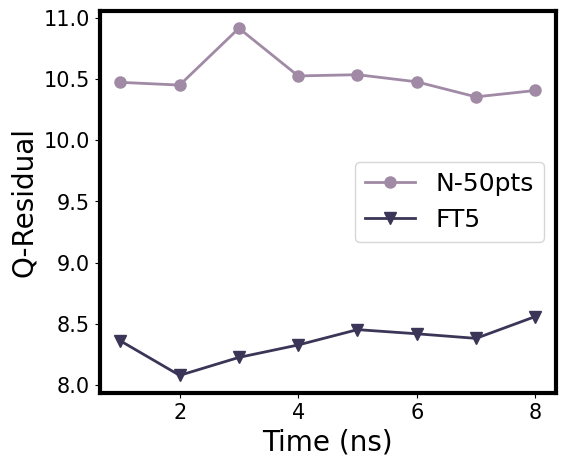

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
num_points = [1, 2, 3, 4, 5, 6, 7, 8]
ax.plot(num_points, naive_residuals_long, '-o', linewidth=2, markersize=8, label='N-50pts', color=colors[2])
# ax.plot(num_points, ft_residuals_long , '--v', linewidth=2, markersize=8, label='Data', color=colors[5])
# ax.plot(num_points, naive_residuals_long_2, '--o', linewidth=2, markersize=8, label='', color=colors[2])
ax.plot(num_points, ft_residuals_long_2 , '-v', linewidth=2, markersize=8, label='FT5', color=colors[5])
ax.set_ylabel("Q-Residual")
ax.set_xlabel("Time (ns)")
ax.legend()
fig.tight_layout()
fig.savefig("figures/results_longQresidual.svg")

In [52]:
# fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
# time = np.linspace(0, 9, 181)
# for i in range(197):
#     if(i==101):
#         ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[0], label='H (102)')
#     elif(i==89):
#         ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='O (90)')
#     elif(i==192):
#         ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[4], label='Cl (193)')
# ax[1].set_xlabel("Time (ns)")
# ax[1].axvline(5.6025, color='black')
# for i in range(197):
#     if(i==146):
#         ax[0].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[0], label='H (147)')
#     elif(i==136):
#         ax[0].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='O (137)')
#     elif(i==191):
#         ax[0].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[4], label='Cl (192)')
# ax[0].set_xlabel("Time (ns)")
# ax[0].set_ylabel("Q-Residual")
# ax[1].set_ylabel(" ")
# # ax[1].tick_params(axis='y', which='both', labelcolor=(0,0,0,0))
# ax[1].set_yticks([10, 20, 30, 40], [10, " ", " ", " "])
# ax[0].set_yticks([10, 20, 30, 40], [10, 20, 30, 40])
# ax[0].axvline(3.1100, color='black')
# ax[0].legend()
# ax[1].legend()
# fig.tight_layout()
# fig.savefig("figures/results_rxnQResiduals.svg")

In [53]:
# Model Dataset
N_10pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-10pts/10pt_dataset_raw.xyz", index=':')
N_21pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-21pts/21pt_dataset_raw.xyz", index=':')
N_31pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-31pts/31pt_dataset_raw.xyz", index=':')
N_40pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-40pts/40pt_dataset_raw.xyz", index=':')
N_50pts_dataset = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
# NP_10pts_dataset = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-10pts/np10pt_dataset_raw.xyz", index=':')
# NP_21pts_dataset = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-21pts/np21pt_dataset_raw.xyz", index=':')
# NP_31pts_dataset = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-31pts/np31pt_dataset_raw.xyz", index=':')
# NP_40pts_dataset = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-40pts/np40pt_dataset_raw.xyz", index=':')
# NP_50pts_dataset = read("../data/ChClCA_Finetuning/Nonperiodic/Finetuned_Models/NP-50pts/np50pt_dataset_raw.xyz", index=':')
ft1_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/u_data_raw.xyz", index=":")
ft2_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft1_data_raw.xyz", index=":")
ft3_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft2_data_raw.xyz", index=":")
ft4_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft3_data_raw.xyz", index=":")
ft5_dataset = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=":")
# Data generated
N_10pts_eval = read("../data/ChClCA_Evaluations/Naive/N-10pts/md/N-10pts_eval_ase.xyz", index='::100')
N_21pts_eval = read("../data/ChClCA_Evaluations/Naive/N-21pts/md/N-21pts_eval_ase.xyz", index='::100')
N_31pts_eval = read("../data/ChClCA_Evaluations/Naive/N-31pts/md/N-31pts_eval_ase.xyz", index='::100')
N_40pts_eval = read("../data/ChClCA_Evaluations/Naive/N-40pts/md/N-40pts_eval_ase.xyz", index='::100')
N_50pts_eval = read("../data/ChClCA_Evaluations/Naive/N-50pts/md/N-50pts_eval_ase.xyz", index='::100')
# NP_10pts_eval = read("../data/ChClCA_Evaluations/Nonperiodic/NP-10pts/md/NP-10pts_eval_ase.xyz", index='::100')
# NP_21pts_eval = read("../data/ChClCA_Evaluations/Nonperiodic/NP-21pts/md/NP-21pts_eval_ase.xyz", index='::100')
# NP_31pts_eval = read("../data/ChClCA_Evaluations/Nonperiodic/NP-31pts/md/NP-31pts_eval_ase.xyz", index='::100')
# NP_40pts_eval = read("../data/ChClCA_Evaluations/Nonperiodic/NP-40pts/md/NP-40pts_eval_ase.xyz", index='::100')
# NP_50pts_eval = read("../data/ChClCA_Evaluations/Nonperiodic/NP-50pts/md/NP-50pts_eval_ase.xyz", index='::100')
ft1_eval = read("../data/ChClCA_Evaluations/Periodic/FT1/md/ft1_eval_ase.xyz", index='::100')
ft2_eval = read("../data/ChClCA_Evaluations/Periodic/FT2/md/ft2_eval_ase.xyz", index='::100')
ft3_eval = read("../data/ChClCA_Evaluations/Periodic/FT3/md/ft3_eval_ase.xyz", index='::100')
ft4_eval = read("../data/ChClCA_Evaluations/Periodic/FT4/md/ft4_eval_ase.xyz", index='::100')
ft5_eval = read("../data/ChClCA_Evaluations/Periodic/FT5/md/ft5_eval_ase.xyz", index='::100')



In [54]:
unique_vals = np.unique(N_10pts_eval[0].arrays['numbers'])
mapping = {val: idx for idx, val in enumerate(unique_vals)}
remapped = np.array([mapping[v] for v in N_10pts_eval[1].arrays['numbers']])

In [55]:
# np_10pt_pca, X_NP_10pts_eval_desc = q_residual_inputs(soap, NP_10pts_dataset, NP_10pts_eval)
# np_21pt_pca, X_NP_21pts_eval_desc = q_residual_inputs(soap, NP_21pts_dataset, NP_21pts_eval)
# np_31pt_pca, X_NP_31pts_eval_desc = q_residual_inputs(soap, NP_31pts_dataset, NP_31pts_eval)
# np_40pt_pca, X_NP_40pts_eval_desc = q_residual_inputs(soap, NP_40pts_dataset, NP_40pts_eval)
# np_50pt_pca, X_NP_50pts_eval_desc = q_residual_inputs(soap, NP_50pts_dataset, NP_50pts_eval)
# np_10pt_residual = plot_q_residuals(np_10pt_pca, X_NP_10pts_eval_desc, colors, remapped, plot=False)
# np_21pt_residual = plot_q_residuals(np_21pt_pca, X_NP_21pts_eval_desc, colors, remapped, plot=False)
# np_31pt_residual = plot_q_residuals(np_31pt_pca, X_NP_31pts_eval_desc, colors, remapped, plot=False)
# np_40pt_residual = plot_q_residuals(np_40pt_pca, X_NP_40pts_eval_desc, colors, remapped, plot=False)
# np_50pt_residual = plot_q_residuals(np_50pt_pca, X_NP_50pts_eval_desc, colors, remapped, plot=False)
# nonperiodic_residuals = [np_10pt_residual, np_21pt_residual, np_31pt_residual, np_40pt_residual, np_50pt_residual]

In [56]:
n_10pt_pca, X_N_10pts_eval_desc = q_residual_inputs(soap, N_10pts_dataset, N_10pts_eval)
n_21pt_pca, X_N_21pts_eval_desc = q_residual_inputs(soap, N_21pts_dataset, N_21pts_eval)
n_31pt_pca, X_N_31pts_eval_desc = q_residual_inputs(soap, N_31pts_dataset, N_31pts_eval)
n_40pt_pca, X_N_40pts_eval_desc = q_residual_inputs(soap, N_40pts_dataset, N_40pts_eval)
n_50pt_pca, X_N_50pts_eval_desc = q_residual_inputs(soap, N_50pts_dataset, N_50pts_eval)
n_10pt_residual = plot_q_residuals(n_10pt_pca, X_N_10pts_eval_desc, colors, remapped, plot=False)
n_21pt_residual = plot_q_residuals(n_21pt_pca, X_N_21pts_eval_desc, colors, remapped, plot=False)
n_31pt_residual = plot_q_residuals(n_31pt_pca, X_N_31pts_eval_desc, colors, remapped, plot=False)
n_40pt_residual = plot_q_residuals(n_40pt_pca, X_N_40pts_eval_desc, colors, remapped, plot=False)
n_50pt_residual = plot_q_residuals(n_50pt_pca, X_N_50pts_eval_desc, colors, remapped, plot=False)
naive_residuals = [n_10pt_residual, n_21pt_residual, n_31pt_residual, n_40pt_residual, n_50pt_residual]
clear_output()

In [57]:
ft1_pca, ft1_eval_desc = q_residual_inputs(soap, ft1_dataset, ft1_eval)
ft2_pca, ft2_eval_desc = q_residual_inputs(soap, ft2_dataset, ft2_eval)
ft3_pca, ft3_eval_desc = q_residual_inputs(soap, ft3_dataset, ft3_eval)
ft4_pca, ft4_eval_desc = q_residual_inputs(soap, ft4_dataset, ft4_eval)
ft5_pca, ft5_eval_desc = q_residual_inputs(soap, ft5_dataset, ft5_eval)
ft1_residual = plot_q_residuals(ft1_pca, ft1_eval_desc, colors, remapped, plot=False)
ft2_residual = plot_q_residuals(ft2_pca, ft2_eval_desc, colors, remapped, plot=False)
ft3_residual = plot_q_residuals(ft3_pca, ft3_eval_desc, colors, remapped, plot=False)
ft4_residual = plot_q_residuals(ft4_pca, ft4_eval_desc, colors, remapped, plot=False)
ft5_residual = plot_q_residuals(ft5_pca, ft5_eval_desc, colors, remapped, plot=False)
ft_residuals = [ft1_residual, ft2_residual, ft3_residual, ft4_residual, ft5_residual]
clear_output()

In [58]:
# fig, ax = plt.subplots(1, 2, figsize=(12,5))
# ax[0].plot(naive_residuals, '-x', linewidth=2, markersize=8, label='Naive', color=colors[1])
# ax[0].plot(nonperiodic_residuals, '-o', linewidth=2, markersize=8, label='Nonperiodic', color=colors[3])
# ax[0].plot(ft_residuals , '-v', linewidth=2, markersize=8, label='Periodic', color=colors[5])
# ax[0].set_xticks([0, 1, 2, 3, 4], ["FT1/10pts", "FT2/21pts", "FT3/31pts", "FT4/40pts", "FT5/50pts"], fontsize=13)
# ax[0].set_ylabel("Q-Residual")
# ax[0].set_xlabel("Model")
# ax[0].legend()
# Q_per_type = pd.read_csv("./data_subsets/Q_residuals_per_type.txt", sep='\t')
# naive_models_Q = Q_per_type[:5]
# periodic_models_Q = Q_per_type[5:]
# for idx, element in enumerate(periodic_models_Q):
#     range_x = np.linspace(0, 4, 5)
#     if(idx==0):
#         continue
#     if(element=='Co'):
#         ax[1].plot(range_x, periodic_models_Q[element][:5], linestyle=(0, (5, 10)), marker=r"$ {} $".format(element), color=colors[5], markersize=12, alpha=0.75)
#         ax[1].plot(range_x, naive_models_Q[element][:5], linestyle=(0, (5, 10)), marker=r"$ {} $".format(element), color=colors[2], markersize=12, alpha=0.75)
#     else:
#         ax[1].plot(range_x, periodic_models_Q[element][:5], linestyle=(0, (5, 10)), marker=r"$ {} $".format(element), color=colors[5], markersize=8, alpha=0.75)
#         ax[1].plot(range_x, naive_models_Q[element][:5], linestyle=(0, (5, 10)), marker=r"$ {} $".format(element), color=colors[2], markersize=8, alpha=0.75)
#     ax[1].set_xticks([0, 1, 2, 3, 4], ["FT1/10pts", "FT2/21pts", "FT3/31pts", "FT4/40pts", "FT5/50pts"], fontsize=13)
#     ax[1].set_yticks([10, 20, 30, 40, 50], [10, 20, 30, 40, 50])
#     ax[1].set_xlabel("Model")
#     ax[1].set_ylabel("Q-residual")
# line_periodic = Line2D([0,1], [0,1], linestyle=(0, (5, 10)), color=colors[5])
# line_naive = Line2D([0,1], [0,1], linestyle=(0, (5, 10)), color=colors[2])
# ax[1].legend([line_naive, line_periodic], ['Naive', 'Periodic'])
# fig.tight_layout()
# plt.savefig("figures/results_testingQResiduals.svg")

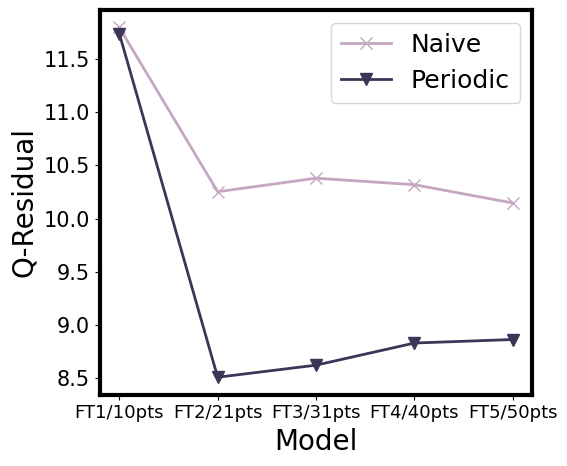

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.plot(naive_residuals, '-x', linewidth=2, markersize=8, label='Naive', color=colors[1])
# ax.plot(nonperiodic_residuals, '-o', linewidth=2, markersize=8, label='Nonperiodic', color=colors[3])
ax.plot(ft_residuals , '-v', linewidth=2, markersize=8, label='Periodic', color=colors[5])
ax.set_xticks([0, 1, 2, 3, 4], ["FT1/10pts", "FT2/21pts", "FT3/31pts", "FT4/40pts", "FT5/50pts"], fontsize=13)
ax.set_ylabel("Q-Residual")
ax.set_xlabel("Model")
ax.legend()
fig.tight_layout()
plt.savefig("figures/results_testQResiduals.svg")

## Reaction Projections

In [60]:
naive_reacted_images = read("./data_subsets/naive_reacted_images.xyz", index=":")
naive_reacted_eval_desc   = [soap.create(atoms, centers=atoms.get_positions(wrap=True)) for atoms in naive_reacted_images]
X_eval_naive_reacted = np.array(naive_reacted_eval_desc).reshape(-1, naive_reacted_eval_desc[0].shape[-1])
X_eval_naive_reacted_pca = pca.transform(X_eval_naive_reacted)
periodic_reacted_images = read("./data_subsets/periodic_reacted_images.xyz", index=":")
periodic_reacted_eval_desc   = [soap.create(atoms, centers=atoms.get_positions(wrap=True)) for atoms in periodic_reacted_images]
X_eval_periodic_reacted = np.array(periodic_reacted_eval_desc).reshape(-1, periodic_reacted_eval_desc[0].shape[-1])
X_eval_periodic_reacted_pca = pca.transform(X_eval_periodic_reacted)
X_eval_naive_reacted_pca = X_eval_naive_reacted_pca.reshape(4, 197, 5)
X_eval_periodic_reacted_pca = X_eval_periodic_reacted_pca.reshape(50, 197, 5)

In [61]:
first_range = []
for i in range(0,4):
    first_range.extend(np.where(naive_reacted_images[i].arrays['id']==123)[0])
second_range = []
for i in range(4,50):
    second_range.extend(np.where(periodic_reacted_images[i].arrays['id']==186)[0])


In [62]:
# fig, ax = plt.subplots(1, 2, figsize=(12,5))
# # ax[0].scatter(X_eval_naive_pca[:, 0], X_eval_naive_pca[:, 1],
# #            alpha=1, label="Naive Trajectory", s=1, color=colors[0], rasterized=True)
# ax[0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='lightgrey', 
#            label='Naive Dataset', rasterized=True)
# for i in range(0,4):
#     ax[0].scatter(X_eval_naive_reacted_pca[i, first_range[i], 0], X_eval_naive_reacted_pca[i, first_range[i], 1],
#                 alpha=1, s=25, marker='o', rasterized=True, color=colors[5], label="H-Cl" if i == 0 else "_nolegend_")
# ax[1].scatter(X_eval_periodic_reacted_pca[:, :, 0], X_eval_periodic_reacted_pca[:, :, 1], s=1, alpha=1, color='lightgrey', 
#            label='Periodic Dataset', rasterized=True)
# for i in range(4, 50):
#     ax[1].scatter(X_eval_periodic_reacted_pca[i, second_range[i-4], 0], X_eval_periodic_reacted_pca[i, second_range[i-4], 1], 
#                   s=25, alpha=1, marker='o', rasterized=True, color=colors[5], label="H-Cl" if i == 4 else "_nolegend_")
# # for i in range(7, 18):
# #     ax[0].scatter(X_eval_naive_reacted_pca[i, second_range[i-7], 0], X_eval_naive_reacted_pca[i, second_range[i-7], 1],
# #                   alpha=1, s=10, color=colors[0], rasterized=True)
# # ax[1].scatter(X_eval_periodic_pca[:, 0], X_eval_periodic_pca[:, 1],
# #            alpha=1, label="Periodic Trajectory", s=1, color=colors[1], rasterized=True)
# for a in ax:
#     # Make tick labels invisible but keep them in the layout
#     a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
#     # Make tick marks invisible but still exist
#     a.tick_params(axis='both', which='both', color=(0,0,0,0))

# ax[0].set_xlabel("PC2")
# ax[0].set_ylabel("PC1")
# ax[1].set_xlabel("PC1")
# ax[1].set_ylabel("PC2")
# ax[0].legend(markerscale=1)
# ax[1].legend(markerscale=1)
# fig.tight_layout()
# fig.savefig("./figures/results_pcaHClReaction.svg")

In [63]:
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
species = set()
for atoms in naive_set:
    species.update(atoms.get_chemical_symbols())
species = list(species)
soap = SOAP(
    species=species,
    r_cut=5,
    n_max=8,
    l_max=6,
    sigma=0.375,
    periodic=True,
    sparse=False
)
time = np.linspace(0, 9, 181)

In [64]:
# Generate SOAP
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
naive_pca = PCA(n_components=5)
X_naive_pca = naive_pca.fit_transform(X_naive)


In [65]:
# reaction_2_traj = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_2_ase.xyz", index="5600:5650")

In [66]:
reaction_traj = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_1_ase.xyz", index="6520:6535")
reaction_2_traj = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_2_ase.xyz", index="2605:2615")

In [67]:
reaction_occuring_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in reaction_traj]
X_rxn = np.array(reaction_occuring_desc).reshape(-1, reaction_occuring_desc[0].shape[-1])
X_rxn_pca = naive_pca.transform(X_rxn)
X_rxn_pca = X_rxn_pca.reshape(15, 197, 5)
reaction_2_occuring_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in reaction_2_traj]
X_rxn_2 = np.array(reaction_2_occuring_desc).reshape(-1, reaction_2_occuring_desc[0].shape[-1])
X_rxn_2_pca = naive_pca.transform(X_rxn_2)
X_rxn_2_pca = X_rxn_2_pca.reshape(10, 197, 5)

In [68]:
# fig, ax = plt.subplots(1, 2, figsize=(12,5))

# ax[0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='black', 
#            label='Naive Dataset', rasterized=True)
# ax[0].scatter(X_rxn_pca[:, 146, 0], X_rxn_pca[:, 146, 1],
#            alpha=1, label="H (147)", marker='x', s=10, color=colors[2], rasterized=True)
# ax[0].scatter(X_rxn_pca[:, 136, 0], X_rxn_pca[:, 136, 1],
#            alpha=1, label="O (137)", marker='o', s=10, color=colors[2], rasterized=True)
# ax[0].scatter(X_rxn_pca[:, 191, 0], X_rxn_pca[:, 191, 1],
#            alpha=1, label="Cl (192)", s=10, marker='v', color=colors[2], rasterized=True)
# ax[1].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='black', 
#            label='Naive Dataset', rasterized=True)
# ax[1].scatter(X_rxn_2_pca[:, 101, 0], X_rxn_2_pca[:, 101, 1],
#            alpha=1, label="H (102)", marker='x', s=10, color=colors[2], rasterized=True)
# ax[1].scatter(X_rxn_2_pca[:, 89, 0], X_rxn_2_pca[:, 89, 1],
#            alpha=1, label="O (90)", marker='o', s=10, color=colors[2], rasterized=True)
# ax[1].scatter(X_rxn_2_pca[:, 192, 0], X_rxn_2_pca[:, 192, 1],
#            alpha=1, label="Cl (193)", s=10, marker='v', color=colors[2], rasterized=True)

# ax[0].set_xlabel("PC1")
# ax[0].set_ylabel("PC2")
# # ax[0].legend(markerscale=5, loc='upper right')
# # ax[1].legend(markerscale=5, loc='upper right')
# ax[1].set_xlabel("PC1")
# ax[1].set_ylabel("PC2")

# for a in ax:
#     a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
#     a.tick_params(axis='both', which='both', color=(0,0,0,0))
# fig.tight_layout()
# plt.savefig("figures/results_HClReactions.svg")
# plt.show()

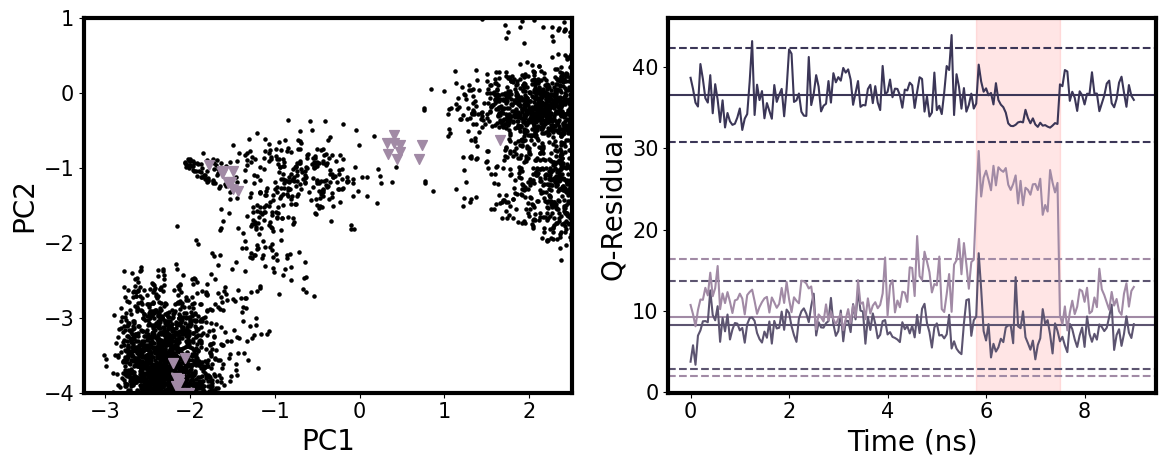

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=False)
ax[1].axvspan(5.8, 7.5, color='red', alpha=0.1)
# ax[1].axvline(5.8, color='red', alpha=1)
# ax[1].axvline(7.5, color='red', alpha=1)
ax[0].set_xlim(-3.25, 2.5)
ax[0].set_ylim(-4, 1)
# ax[0].tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
# ax[0].tick_params(axis='both', which='both', color=(0,0,0,0))
ax[1].axhline(2*3.588+9.223, color=colors[2], ls='dashed')
ax[1].axhline(9.223, color=colors[2])
ax[1].axhline(9.223-2*3.588, color=colors[2], ls='dashed')
ax[1].axhline(2*2.897+36.556, color=colors[5], ls='dashed')
ax[1].axhline(36.556, color=colors[5])
ax[1].axhline(36.556-2*2.897, color=colors[5], ls='dashed')
ax[1].axhline(2*2.710+ 8.316, color=colors[4], ls='dashed')
ax[1].axhline(8.316, color=colors[4])
ax[1].axhline(8.316-2*2.710, color=colors[4], ls='dashed')
ax[0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=5, alpha=1, color='black', 
           label='Naive Dataset', rasterized=True)
ax[0].scatter(X_rxn_2_pca[:, 101, 0], X_rxn_2_pca[:, 101, 1],
           alpha=1, label="H (102)", marker='v', s=50, color=colors[2], rasterized=True)
ax[0].scatter(X_rxn_2_pca[:, 89, 0], X_rxn_2_pca[:, 89, 1],
           alpha=1, label="O (90)", marker='v', s=50, color=colors[2], rasterized=True)
ax[0].scatter(X_rxn_2_pca[:, 192, 0], X_rxn_2_pca[:, 192, 1],
           alpha=1, label="Cl (193)", s=50, marker='v', color=colors[2], rasterized=True)
for i in range(197):
    if(i==101):
        ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='H (102)')
    elif(i==89):
        ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[4], label='O (90)')
    elif(i==192):
        ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[5], label='Cl (193)')
ax[1].set_xlabel("Time (ns)")
ax[0].set_xlabel("PC1")
ax[1].set_ylabel("Q-Residual")
ax[0].set_ylabel("PC2")

# ax[1].tick_params(axis='y', which='both', labelcolor=(0,0,0,0))
# ax[1].set_yticks([10, 20, 30, 40], [10, " ", " ", " "])
# ax[0].axvline(3.1100, color='black')
# ax[0].legend()
fig.tight_layout()
# fig.savefig("figures/results_rxn_5ns_qresidual.svg")

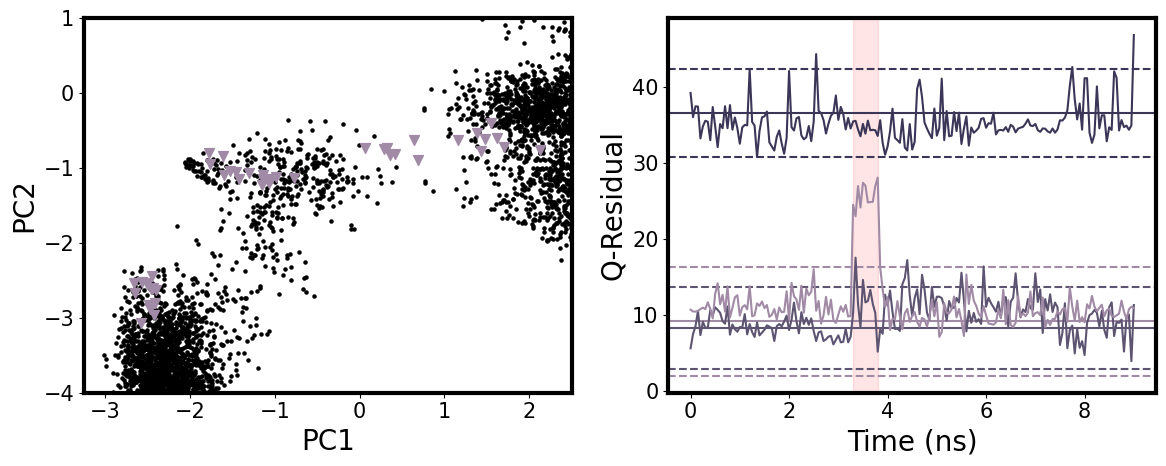

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=False)
ax[1].set_xlabel("Time (ns)")
ax[0].set_xlabel("PC1")
ax[1].set_ylabel("Q-Residual")
ax[0].set_ylabel("PC2")
ax[1].axvspan(3.3, 3.8, color='red', alpha=0.1)
# ax[1].axvline(3.3, color='red', alpha=1)
# ax[1].axvline(3.8, color='red', alpha=1)
ax[1].axhline(2*3.588+9.223, color=colors[2], ls='dashed')
ax[1].axhline(9.223, color=colors[2])
ax[1].axhline(9.223-2*3.588, color=colors[2], ls='dashed')
ax[1].axhline(2*2.897+36.556, color=colors[5], ls='dashed')
ax[1].axhline(36.556, color=colors[5])
ax[1].axhline(36.556-2*2.897, color=colors[5], ls='dashed')
ax[1].axhline(2*2.710+ 8.316, color=colors[4], ls='dashed')
ax[1].axhline(8.316, color=colors[4])
ax[1].axhline(8.316-2*2.710, color=colors[4], ls='dashed')
ax[0].set_xlim(-3.25, 2.5)
ax[0].set_ylim(-4, 1)
# ax[0].tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
# ax[0].tick_params(axis='both', which='both', color=(0,0,0,0))
ax[0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=5, alpha=1, color='black', 
           label='Naive Dataset', rasterized=True)
ax[0].scatter(X_rxn_pca[:, 146, 0], X_rxn_pca[:, 146, 1],
           alpha=1, label="H (147)", marker='v', s=50, color=colors[2], rasterized=True)
ax[0].scatter(X_rxn_pca[:, 136, 0], X_rxn_pca[:, 136, 1],
           alpha=1, label="O (137)", marker='v', s=50, color=colors[2], rasterized=True)
ax[0].scatter(X_rxn_pca[:, 191, 0], X_rxn_pca[:, 191, 1],
           alpha=1, label="Cl (192)", s=50, marker='v', color=colors[2], rasterized=True)
for i in range(197): 
    if(i==146):
        ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='H (147)')
    # elif(i==95):
    #     ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color='red', label='C(OH)2')
    elif(i==136):
        ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[4], label='O (137)')
    elif(i==191):
        ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[5], label='Cl (192)')

# ax[1].tick_params(axis='y', which='both', labelcolor=(0,0,0,0))
# ax[1].set_yticks([10, 20, 30, 40], [10, " ", " ", " "])
# ax[0].axvline(3.1100, color='black')
# ax[0].legend()
fig.tight_layout()
fig.savefig("figures/results_rxn_3ns_qresidual.svg")

# Co Analysis

In [71]:
extrap_phase = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_1_ase.xyz", index=slice(1000, 9000, 200)) + read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_2_ase.xyz", index=slice(0, 2800, 200))
interp_phase = read("../data/ChClCA_Evaluations/Long_Runs/Naive/md/long_naive_2_ase.xyz", index=slice(3000, 9000, 200))

In [72]:
extrap_phase_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in extrap_phase]
interp_phase_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in interp_phase]
X_extrap_phase_desc = np.array(extrap_phase_desc).reshape(-1, extrap_phase_desc[0].shape[-1])
X_interp_phase_desc = np.array(interp_phase_desc).reshape(-1, interp_phase_desc[0].shape[-1])
X_extrap_pca = naive_pca.transform(X_extrap_phase_desc)
X_interp_pca = naive_pca.transform(X_interp_phase_desc)


In [73]:
X_extrap_pca = X_extrap_pca.reshape(54, 197, 5)
X_interp_pca = X_interp_pca.reshape(30, 197, 5)
X_pca_reshaped = X_naive_pca.reshape(50, 197, 5)

In [74]:
# fig, ax = plt.subplots(1, 1, figsize=(6, 5))
# ax.scatter(X_pca_reshaped[:, 1, 0], X_pca_reshaped[:, 1, 1], s=5, alpha=1, color=colors[5], 
#            label='Cobalt Dataset')
# ax.scatter(X_extrap_pca[:, 0, 0], X_extrap_pca[:, 0, 1], s=5, alpha=1, color=colors[3], 
#            label=r'$\mathregular{CoCl_3}$')
# ax.scatter(X_interp_pca[:, 0, 0], X_interp_pca[:, 0, 1], s=5, alpha=1, color=colors[0], 
#            label=r'$\mathregular{CoCl_4}$')
# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
# ax.tick_params(axis='both', which='both', color=(0,0,0,0))
# ax.legend(markerscale=5)
# ax.set_xlim([-2.5, 0])
# ax.set_ylim([-2.5, 0])
# fig.tight_layout()
# fig.savefig("figures/results_cobaltPCA.svg")

In [75]:
X_naive_pca_r=X_naive_pca.reshape(50,197,5)

In [76]:
print(np.mean(compute_q_residuals(naive_pca, X_eval_naive[1::197])))
print(np.std(compute_q_residuals(naive_pca, X_eval_naive[1::197])))

44.845971088869874
6.3716146900678625


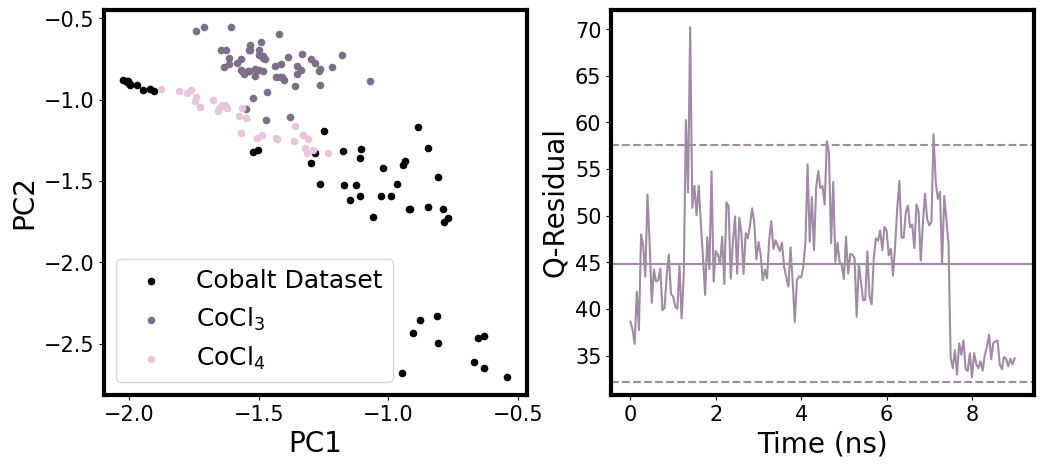

In [ ]:
# SI, cobalt Q-residuals
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=False)
# ax[0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=5, alpha=1, color='black', 
#            label='Naive Dataset', rasterized=True)
ax[0].scatter(X_pca_reshaped[:, 1, 0], X_pca_reshaped[:, 1, 1], s=20, alpha=1, color='black', 
           label='Cobalt Dataset')
ax[0].scatter(X_extrap_pca[:, 0, 0], X_extrap_pca[:, 0, 1], s=20, alpha=1, color=colors[3], 
           label=r'$\mathregular{CoCl_3}$')
ax[0].scatter(X_interp_pca[:, 0, 0], X_interp_pca[:, 0, 1], s=20, alpha=1, color=colors[0], 
           label=r'$\mathregular{CoCl_4}$')
# ax[0].scatter(X_rxn_pca[:, 136, 0], X_rxn_pca[:, 136, 1],
#            alpha=1, label="O (137)", marker='v', s=50, color=colors[2], rasterized=True)
# ax[0].scatter(X_rxn_pca[:, 191, 0], X_rxn_pca[:, 191, 1],
#            alpha=1, label="Cl (192)", s=50, marker='v', color=colors[2], rasterized=True)
for i in range(197):
    if(i==1):
        ax[1].plot(time, compute_q_residuals(naive_pca, X_eval_naive[i::197]), color=colors[2], label='Q_Co')
ax[1].set_xlabel("Time (ns)")
ax[0].set_xlabel("PC1")
ax[1].set_ylabel("Q-Residual")
ax[0].set_ylabel("PC2")
# ax[1].axvspan(3.3, 3.8, color='red', alpha=0.1)
# ax[1].axhline(2*3.588+9.223, color=colors[2], ls='dashed')
# ax[1].axhline(9.223, color=colors[2])
# ax[1].axhline(9.223-2*3.588, color=colors[2], ls='dashed')
# ax[1].axhline(2*2.897+36.556, color=colors[5], ls='dashed')
ax[1].axhline(44.846, color=colors[2])
ax[1].axhline(44.846-2*6.37, color=colors[2], ls='dashed')
ax[1].axhline(44.846+2*6.37, color=colors[2], ls='dashed')
# ax[1].axhline(8.316, color=colors[4])
# ax[1].axhline(8.316-2*2.710, color=colors[4], ls='dashed')
# ax[0].set_xlim(-3.25, 2.5)
# ax[0].set_ylim(-4, 1)
# ax[0].tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
# ax[0].tick_params(axis='both', which='both', color=(0,0,0,0))
# ax[1].tick_params(axis='y', which='both', labelcolor=(0,0,0,0))
# ax[1].set_yticks([10, 20, 30, 40], [10, " ", " ", " "])
# ax[0].axvline(3.1100, color='black')
ax[0].legend()
# ax[0].legend()
# fig.tight_layout()
fig.savefig("figures/results_cobaltPCA.svg")

# Force parity plots

In [5]:
naive_traj = get_DFT_from_directory("../data/ChClCA_Evaluations/Long_Runs/Naive/dft")
periodic_traj = get_DFT_from_directory("../data/ChClCA_Evaluations/Long_Runs/Periodic/dft")
xyzs_n = {}
for fname in sorted(os.listdir("../data/ChClCA_Evaluations/Long_Runs/Naive/dft")):
    timestep = int(fname.split(".")[1])
    xyzs_n[timestep] = read(os.path.join("../data/ChClCA_Evaluations/Long_Runs/Naive/dft", fname + '/POSCAR'))
xyzs_p = {}
for fname in sorted(os.listdir("../data/ChClCA_Evaluations/Long_Runs/Periodic/dft")):
    timestep = int(fname.split(".")[1])
    xyzs_p[timestep] = read(os.path.join("../data/ChClCA_Evaluations/Long_Runs/Periodic/dft", fname + '/POSCAR'))

In [7]:
forces_by_type_n = defaultdict(list)
forces_by_type_p = defaultdict(list)
for key, structure in xyzs_n.items():
    structure.calc = N_50pts_model
    forces = structure.get_forces()
    magnitudes = np.linalg.norm(forces, axis=-1)
    for atom_type, mag in zip(structure.symbols, magnitudes):
        forces_by_type_n[atom_type].append(mag)
for key, structure in xyzs_p.items():
    structure.calc = FT5_model
    forces = structure.get_forces()
    magnitudes = np.linalg.norm(forces, axis=-1)
    for atom_type, mag in zip(structure.symbols, magnitudes):
        forces_by_type_p[atom_type].append(mag)

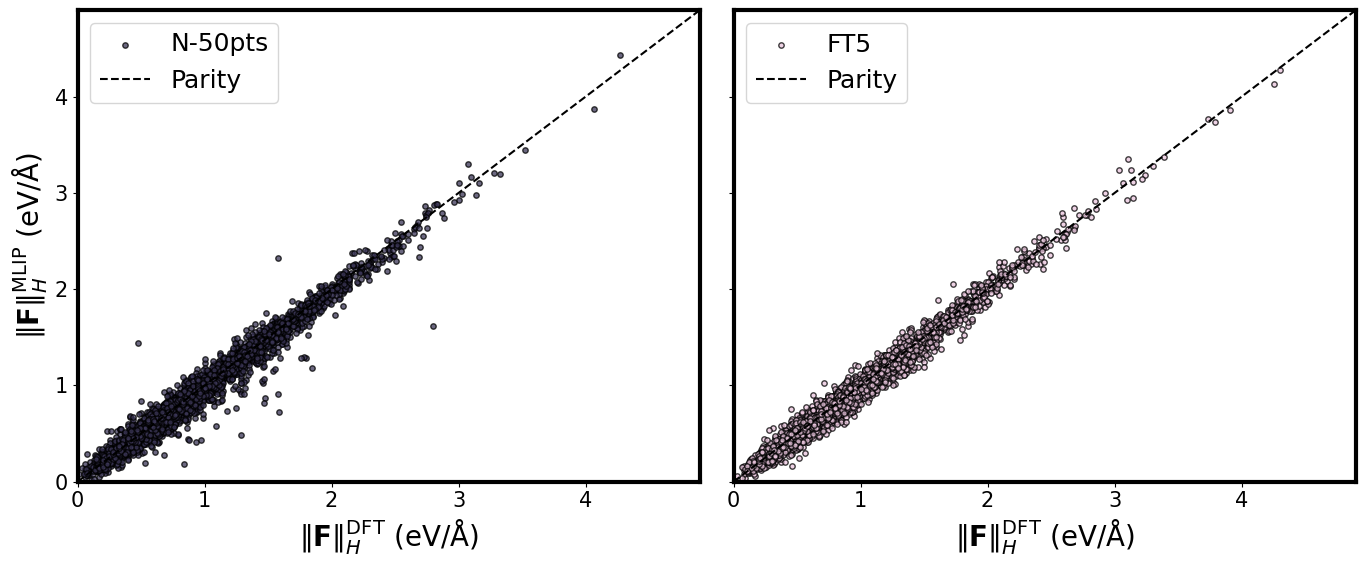

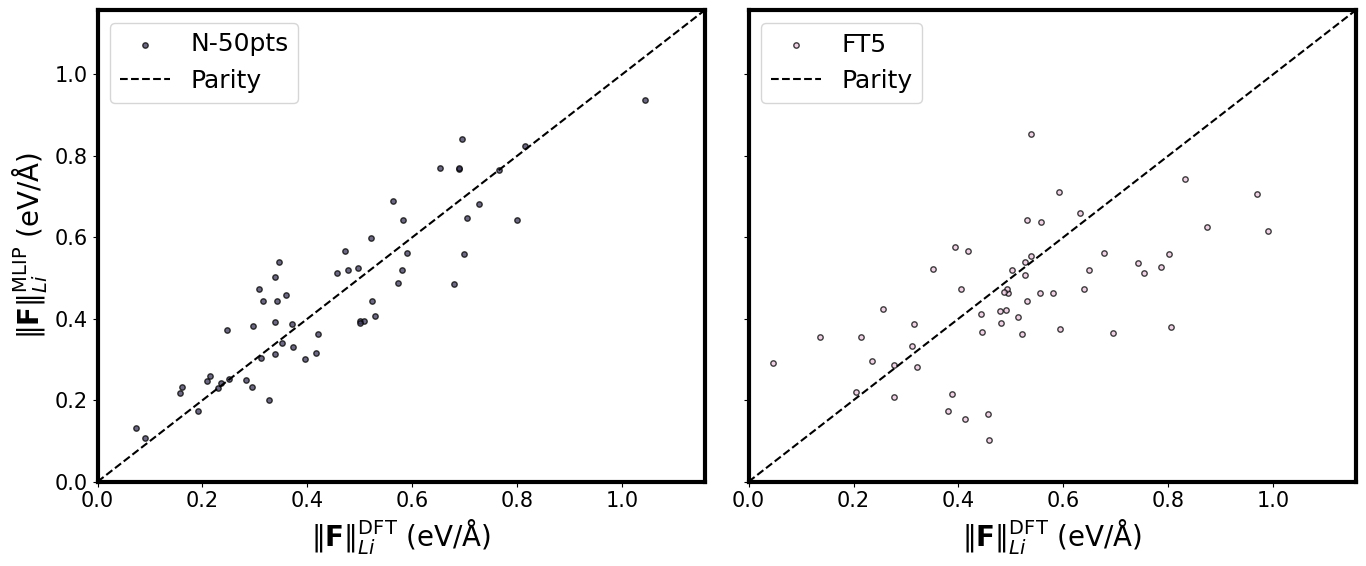

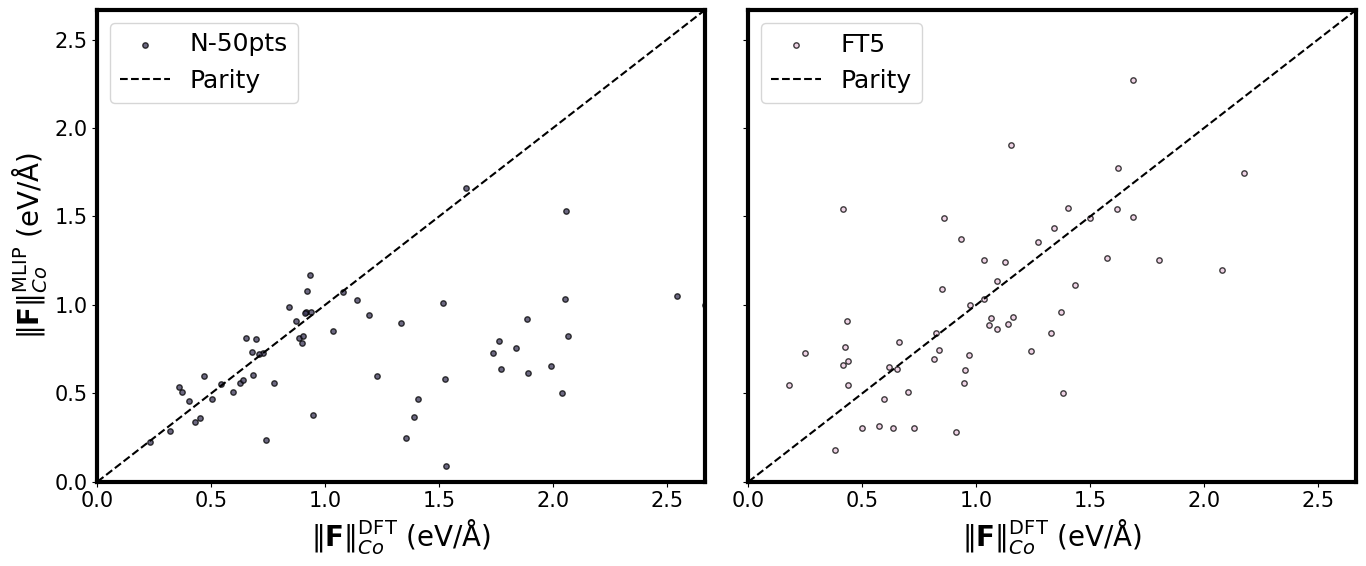

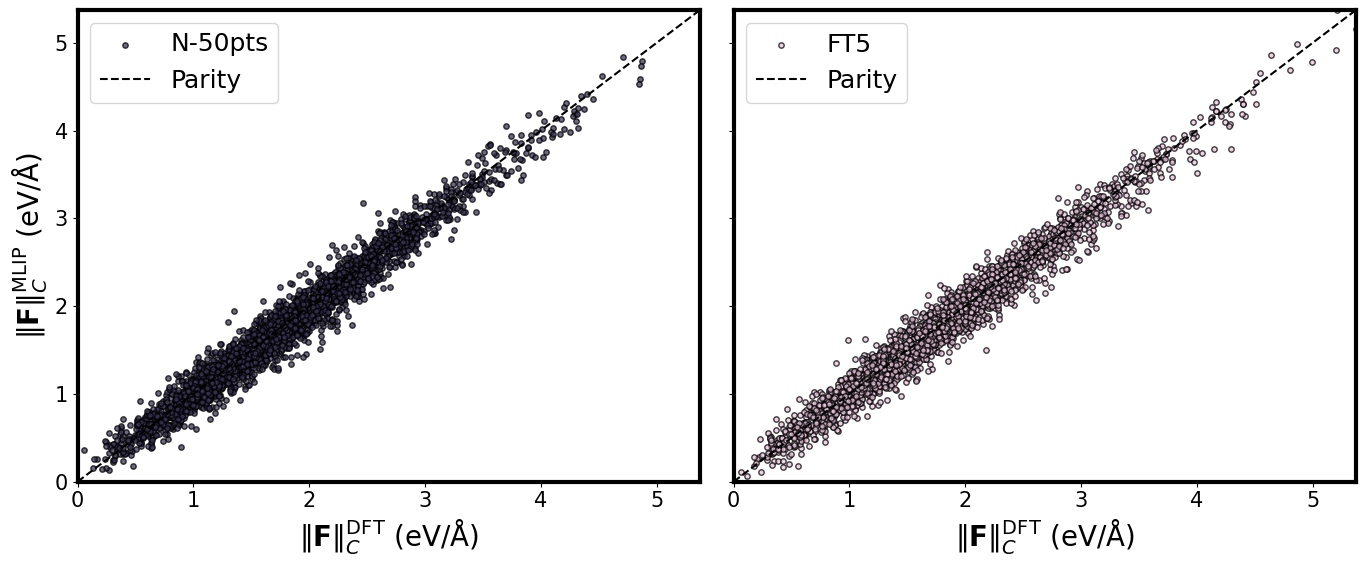

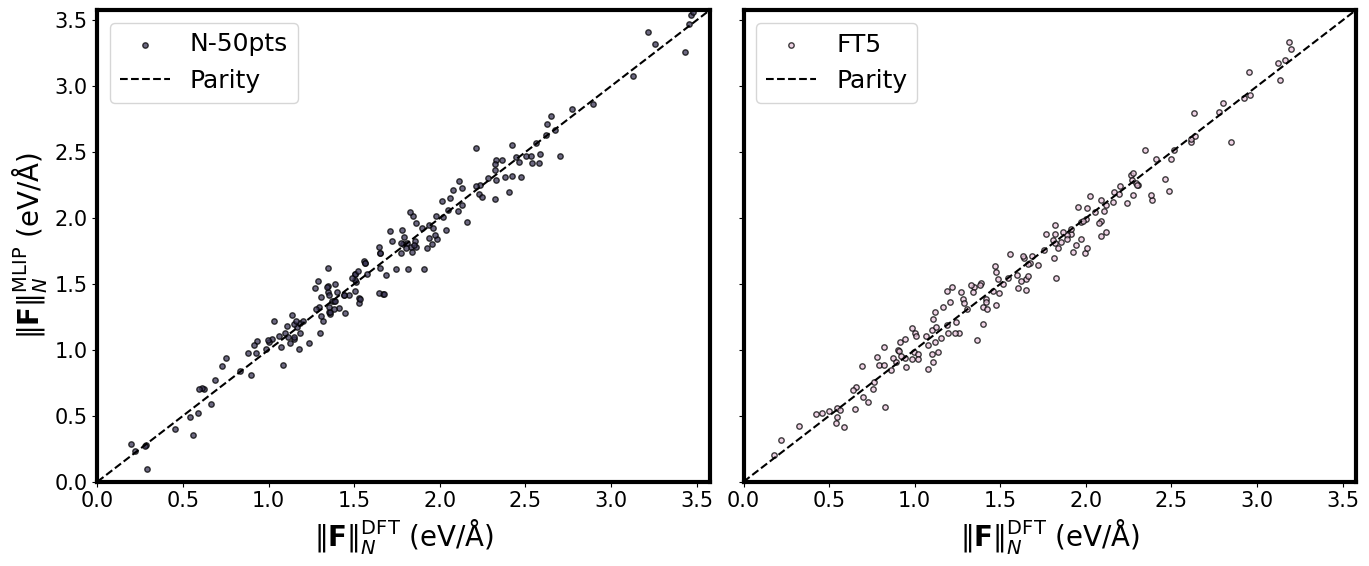

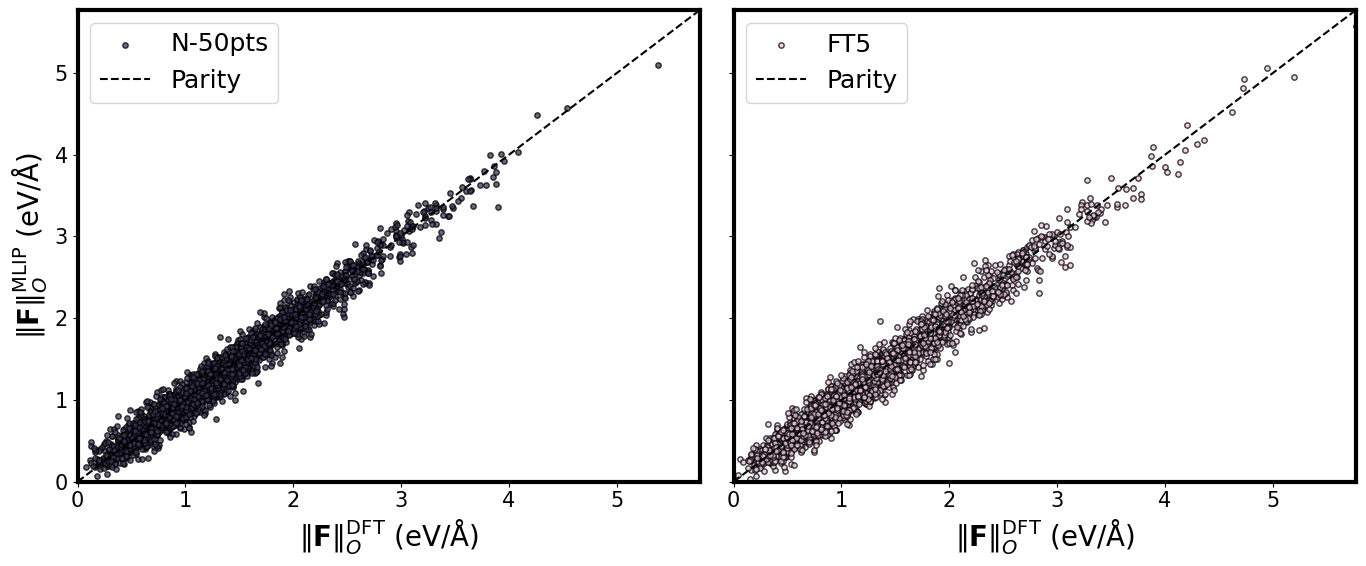

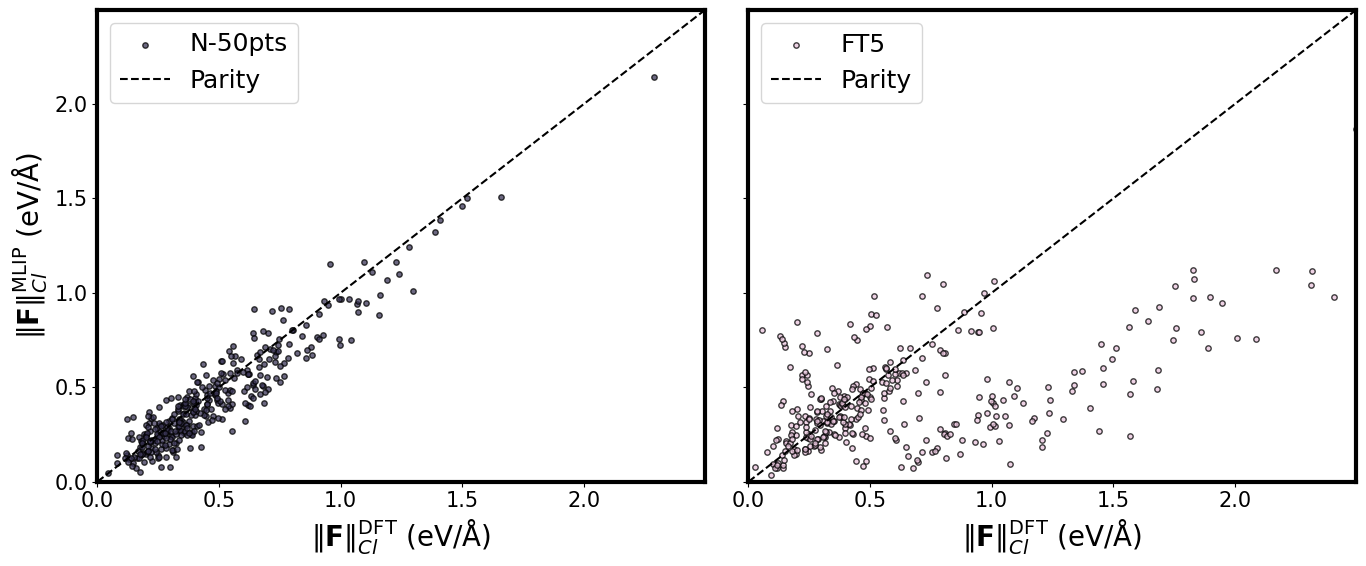

In [9]:
for element in ["H", "Li", "Co", "C", "N", "O", "Cl"]:
    n50pts_forces = []
    atom_focus=element
    for timestep, dftinfo in naive_traj.items():
        if not dftinfo.success:
            continue
        forces = dftinfo.forces
        structure = dftinfo.structure
        atom_types = [site.species_string for site in structure.sites]
        magnitudes = np.linalg.norm(forces, axis=-1)
        for atom_type, mag in zip(atom_types, magnitudes):
            if atom_type == atom_focus:
                n50pts_forces.append(mag)
    ft5_forces = []
    for timestep, dftinfo in periodic_traj.items():
        if not dftinfo.success:
            continue
        
        forces = dftinfo.forces
        structure = dftinfo.structure
        atom_types = [site.species_string for site in structure.sites]
        magnitudes = np.linalg.norm(forces, axis=-1)
        for atom_type, mag in zip(atom_types, magnitudes):
            if atom_type == atom_focus:
                ft5_forces.append(mag)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    max_force = max(max(ft5_forces), max(n50pts_forces))
    axes[1].scatter(
        ft5_forces,
        forces_by_type_p[atom_focus],
        alpha=0.75,
        color=colors[0],
        edgecolors='k',
        s=15,
        label='FT5',
        rasterized=True
    )
    axes[1].plot([0, max_force], [0, max_force], 'k--', label='Parity')
    axes[1].set_xlim([0, max_force])
    axes[1].set_ylim([0, max_force])
    axes[1].set_xlabel(f"$\\|\\mathbf{{F}}\\|_{{{element}}}^{{\\mathrm{{DFT}}}}$ (eV/Å)")
    axes[0].set_ylabel(f"$\\|\\mathbf{{F}}\\|_{{{element}}}^{{\\mathrm{{MLIP}}}}$ (eV/Å)")
    axes[1].legend()
    axes[0].scatter(
        n50pts_forces,
        forces_by_type_n[atom_focus],
        alpha=0.75,
        color=colors[5],
        edgecolors='k',
        s=15,
        label='N-50pts',
        rasterized=True
    )
    axes[0].plot([0, max_force], [0, max_force], 'k--', label='Parity')
    axes[0].set_xlim([0, max_force])
    axes[0].set_ylim([0, max_force])
    axes[0].set_xlabel(f"$\\|\\mathbf{{F}}\\|_{{{element}}}^{{\\mathrm{{DFT}}}}$ (eV/Å)")
    axes[0].legend()
    plt.tight_layout()
    if(element=="H"):
        fig.savefig(f"figures/discussion_{element}_forces.svg")
    else:
        fig.savefig(f"supplemental_figs/SI_{element}_forces.svg")
    plt.show()